# Temperature Analysis

This notebook uses light cure data from LSST in order to estimate the temperature of an object.

The main way this is done is by fitting a black body curve to the flux measured across several filters. The results of this are plotted daily from data taken over a default rolling window of 3 days.

In addition temperature is also found using pairs of filters. This method is substantially worse at estimating temperature but it can be useful in seeing trends that might suggest that this might not be a black body source. More information on this method and its limitations can be seen in the pair analysis section.

This notebook provides a way to plot this data for a given object in the Pitt-Google brokers database. Several examples of this are plotted at the end of this notebook.

Some of this code mostly the pair analysis section is directly from or modified from lasair. Any code of this nature will be labeled as such in the markdown text above it and as a comment on the first line of the code block.

## Prerequisites
- Complete the [One-Time Setup](https://mwvgroup.github.io/pittgoogle-client/one-time-setup/index.html), specifically:
     - Install the pittgoogle-client package
     - Setup authentication to a Google Cloud project
     - Set environment variables
     - Enable the BigQuery API
     - You can skip the command-line tools

In [1]:
import pittgoogle
pgb_project = "pitt-alert-broker" # define the Pitt-Google Alert Broker's GCP project name
bqclient = pittgoogle.bigquery.Client() # load the BigQuery client

# makes matplotlib plots interactive
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.container import ErrorbarContainer

from scipy.optimize import curve_fit
import numpy as np
import pandas as pd
import math

# for saving sql query results
import pickle
from pathlib import Path
import os

import mwdust
# Initialize the 2D SFD dust map
sfdMap = mwdust.SFD(filter='E(B-V)')

from astropy.coordinates import SkyCoord
from astropy.stats import sigma_clip
from astropy.time import Time

from itertools import compress
from itertools import repeat

In [2]:
# The LSST bands, wavelength in microns from https://lsstcam.lsst.io/
WL = {'u': 0.3724, 'g': 0.4807, 'r': 0.6221, 'i': 0.7559, 'z': 0.8680, 'y': 0.9753}

From Lasiar Examples

These coefficients are for the extinction correction. 
For the g-filter, for example, an E(B-V) value of 0.5 
would increase the g magnitude number by 0.5*3.237 = 1.618 mags,
equivalently decrease the flux by a factor of 10^(1.618/2.5) = 4.43.

These colour corrections are from Table 6 of 
[Schlafly and Finkbeiner](https://iopscience.iop.org/article/10.1088/0004-637X/737/2/103) with RV=3.1

In [3]:
# From Lasiar Examples
# Multiplier for EBV for magnitude correction
EXTCOEF   = {'u': 4.145, 'g': 3.237, 'r': 2.273, 'i': 1.684, 'z': 1.323, 'y': 1.088}

### Blackbody spectrum

Modified from Lasiar Examples

This formula is "per Hertz" to match up with the definition of Jansky.
The number 'hck' is planck * speed of light / boltzmann, with temperature in kilokelvin and wavelength in microns.
In addition a scale factor is added which accounts for the flux being dependent on object size and distance from us.

In [4]:
# Modified from Lasiar Examples

def scaledBlackbody(wl, T, scale):
    hck = 14.387
    q = np.exp(hck/(wl*T))
    return scale * np.power(wl, -3.0) / (q - 1)

# dustFluxErr would be the same function as dustFlux since the dustFlux is effectively multiplying flux by a constant
def dustFlux(flux, band, ebv):
    return flux*math.pow(10, ebv*EXTCOEF[band]/2.5)

## Plot the light curve and temperatures

### Functions that make the plots

#### Set the Y axis limits

This is done so that zero is always visible in the black body curves and so that extreme error bars don't shrink the plot to far.

In [5]:
def setYLimit(ax, yData, includeZero):
    yMax = max(yData)
    yMin = min(0, min(yData)) if includeZero else min(yData)

    margin = (yMax - yMin) * 0.05

    ax.set_ylim(bottom = yMin - margin, top = yMax + margin)

#### Plot the light curve

This function plots the light curve using the colors described for each filter

In [6]:
def plotLightCurve(ax, color, sourceList, pickRadius):
    bars = []
    for band in color.keys():
        mask = (sourceList.band == band) & (~sourceList.isForced)
        fmask = (sourceList.band == band) & (sourceList.isForced)
        mjds = sourceList.loc[mask, 'midpointMjdTai']
        fluxs = sourceList.loc[mask, 'flux']
        fluxErrs = sourceList.loc[mask, 'fluxErr']
        
        fmjds = sourceList.loc[fmask, 'midpointMjdTai']
        ffluxs = sourceList.loc[fmask, 'flux']
        ffluxErrs = sourceList.loc[fmask, 'fluxErr']
                    
        # plot the sources
        bars.append(ax.errorbar(mjds,
                                fluxs,
                                yerr            = fluxErrs,
                                marker          = 'o',
                                markeredgewidth = 0,
                                color           = color[band],
                                linestyle       = 'None',
                                label           = band,
                                picker          = pickRadius))
        
        bars[-1][0].custom_metadata = [{'fluxErr': fluxErr, 'filter': band, 'forcedOrNot': 'Source'}
                                       for fluxErr in fluxErrs]
        
        # plot the forced sources
        bars.append(ax.errorbar(fmjds,
                                ffluxs,
                                yerr            = ffluxErrs,
                                marker          = 'X',
                                markeredgewidth = 0,
                                color           = color[band],
                                linestyle       = 'None',
                                label           = f'forced {band}',
                                picker          = pickRadius))
        
        bars[-1][0].custom_metadata = [{'fluxErr': fluxErr, 'filter': band, 'forcedOrNot': 'Forced Source'}
                                       for fluxErr in ffluxErrs]
    
    # Labels for light curve plot
    ax.set_xlabel('MJD')
    ax.set_ylabel('Flux (nJy)')

    setYLimit(ax, sourceList['flux'], includeZero=True)
    return bars

#### Plot temperature

This function plots the calculated temperature. It shows the pair temperature as dots made up of the colors of the two filters used to calculate the pair temperature. It also shows the fit temperature for a window starting each day where at least 3 filters of data was collected.

In [7]:
def plotTemperature(ax, color, pairTemp, fitTemp, pickRadius, plotLabel=True):
    bars = []
    # Plots the pair analysis results with each half of the point representing one of the filters used
    for i in range(len(pairTemp['temp'])):
        line, = ax.plot(pairTemp['mjd'][i],
                        pairTemp['temp'][i],
                        marker             = 'o',
                        markeredgewidth    = 0,
                        fillstyle          = 'left',
                        markerfacecolor    = color[pairTemp['filter1'][i]],
                        markerfacecoloralt = color[pairTemp['filter2'][i]],
                        picker             = pickRadius)
        line.custom_metadata = {'filter1': pairTemp['filter1'][i],
                                'filter2': pairTemp['filter2'][i]}
        bars.append(line)
    
    if plotLabel:
        label = 'fitTemp'
    else:
        label = '_fitTemp_'
    # plot the results of the fit temp function for each day
    bars.append(ax.errorbar(fitTemp['mjd'],
                            fitTemp['temp'],
                            yerr      = fitTemp['tempErr'],
                            marker    = '*',
                            linestyle = 'None',
                            color     = 'black',
                            label     = label,
                            picker    = pickRadius))
    
    bars[-1][0].custom_metadata = [{'tempErr': tempErr, 'scale': scale, 'scaleErr': scaleErr}
                                  for tempErr, scale, scaleErr in
                                  zip(fitTemp['tempErr'], fitTemp['scale'], fitTemp['scaleErr'])]

    # Labels for temperature plot
    ax.set_xlabel("MJD")
    ax.set_ylabel("Temperature (kK)")

    setYLimit(ax, pairTemp['temp'] + fitTemp['temp'], includeZero=False)
    return bars

#### Plot black body

This function plots the black body curves fitted for each day. This allows inspection of the fit. The color of each line in this plot is based on the day it was taken rather than the filter used like the previous plots. Instead each filter is marked on the x axis.

In [8]:
def plotBlackBody(ax, fitTemp, pickRadius):
    # Setup for the black body plot
    cmap = plt.colormaps['inferno']
    blackbodyColors = cmap(np.linspace(0, 1, len(fitTemp['temp'])))
    x = np.linspace(0, 1.5, 51)[1:]
    markers = ['o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'H', 'D', 'd', 'P', 'X']

    # Plots the fitted black body curve for each day and the points it was fit to
    bars = []
    lines = []
    for i in range(len(fitTemp['temp'])):
        bars.append(ax.errorbar(fitTemp['wavelengths'][i],
                                fitTemp['fluxs'][i],
                                yerr      = fitTemp['fluxErrs'][i],
                                marker    = markers[i%len(markers)], markeredgewidth=0,
                                linestyle = 'None',
                                color     = blackbodyColors[i],
                                label     = f'MJD: {fitTemp['mjd'][i]}',
                                picker    = pickRadius))
        # store info for when a point is clicked on
        bars[-1][0].custom_metadata = {'temp': fitTemp['temp'][i],
                                       'tempErr': fitTemp['tempErr'][i],
                                       'scale': fitTemp['scale'][i],
                                       'scaleErr': fitTemp['scaleErr'][i],
                                       'mjd': fitTemp['mjd'][i]}
        
        y = scaledBlackbody(x, fitTemp['temp'][i], fitTemp['scale'][i])
        line, = ax.plot(x, y, color = blackbodyColors[i])
        lines.append(line)

    # Labels for black body plot
    ax.set_ylabel('Flux (nJy)')
    ax.set_xlabel(r'Wavelength ($\mu$m)')

    # Let the curve go to the edge of the plot
    ax.margins(x=0)

    # add labels for each band in the black body plot
    ax.set_xticks(list(tick for tick in WL.values()), list(f'\n{tick}' for tick in WL.keys()), minor = True)

    return bars, lines

### Make the plot intractable

#### Supporting functions for the legend

These functions are used to allow the lines to be toggled by interacting with them in the legend.

In [9]:
# Setup to connect parts of the legend to the associated lines
def connectLegend(mapLegendToAx, pickRadius, plot, legend, difBar, sciBar, difLine=repeat(None), sciLine=repeat(None)):
    for legendLine, legendText, axDifBar, axDifLine, axSciBar, axSciLine in zip(legend.legend_handles, legend.get_texts(), difBar, difLine, sciBar, sciLine):
        legendLine.set_picker(pickRadius) # Enable picking on the legend line.
        legendText.set_picker(pickRadius) # Enable picking on the legend text.
        mapLegendToAx[legendLine] = {'plot': plot, 'difBar': axDifBar, 'difLine': axDifLine, 'sciBar': axSciBar, 'sciLine': axSciLine, 'text': legendText}
        mapLegendToAx[legendText] = {'plot': plot, 'difBar': axDifBar, 'difLine': axDifLine, 'sciBar': axSciBar, 'sciLine': axSciLine, 'text': legendText}
    return mapLegendToAx

# Showing / hiding lines and dimming the associated legend entries
def setTransparency(line, isVisible):
    if line['plot'] == 'BB':
        line['difLine'].set_visible(isVisible)
        line['sciLine'].set_visible(isVisible)

    line['difBar'][0].set_visible(isVisible)
    line['sciBar'][0].set_visible(isVisible)
    for bar in line['difBar'][1] + line['difBar'][2]:
        bar.set_visible(isVisible)
    for bar in line['sciBar'][1] + line['sciBar'][2]:
        bar.set_visible(isVisible)
    
    line['text'].set_alpha(1.0 if isVisible else 0.2)

#### Supporting functions to click points

This allows the annotations to be generated and moved based on what point was clicked.

##### Get and set the position of an annotation

This moves the annotation to the desired location and returns the position to generate the text.

In [10]:
def moveAnnotation(annotation, event):
    index = event.ind[0]
    clicked_artist = event.artist
    
    xData = clicked_artist.get_xdata()
    yData = clicked_artist.get_ydata()
    
    xPoint = xData[index]
    yPoint = yData[index]

    ax = clicked_artist.axes
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    xMiddle = (xlim[0] + xlim[1]) / 2
    yMiddle = (ylim[0] + ylim[1]) / 2
    
    if xPoint < xMiddle:
        xOffset = 15
        xAlignment = 'left'
    else:
        xOffset = -15
        xAlignment = 'right'
        
    if yPoint < yMiddle:
        yOffset = 15
        yAlignment = 'bottom'
    else:
        yOffset = -15
        yAlignment = 'top'
    

    annotation.xy = (xPoint, yPoint)
    annotation.xyann = (xOffset, yOffset)
    annotation.set_ha(xAlignment)
    annotation.set_va(yAlignment)
    
    return clicked_artist, index, xPoint, yPoint

##### Generate the text for each annotation

These functions generate the text for each annotation based on what plot they are in. Each one not only reports the coordinates for each point but also additional information on each point or line.

In [11]:
def LCAnnotation(annotation, event):
    clicked_artist, index, xPoint, yPoint = moveAnnotation(annotation, event)
    metadata = clicked_artist.custom_metadata[index]
    t = Time(xPoint, format='mjd')

    annotation.set_text(
f"""MJD: {xPoint:.5f}
{t.to_value(format='iso', subfmt='date_hms')[:19]}
Flux: {yPoint:.2f} nJy
Flux Error: {metadata['fluxErr']:.2f} kK
Filter: {metadata['filter']}
{metadata['forcedOrNot']}"""
    )

    annotation.set_visible(True)

def tempAnnotation(annotation, event):
    clicked_artist, index, xPoint, yPoint = moveAnnotation(annotation, event)

    if isinstance(clicked_artist.custom_metadata, list):
        metadata = clicked_artist.custom_metadata[index]
    else:
        metadata = clicked_artist.custom_metadata
    
    t = Time(xPoint, format='mjd')

    if 'scale' in metadata: # if from fit temp not pair temp
        annotation.set_text(
f"""MJD: {xPoint}
{t.to_value(format='iso', subfmt='date')}
Temperature: {yPoint:.2f} kK
Temperature Error: {metadata['tempErr']:.2f} kK
Scale: {metadata['scale']:.2f}
Scale Error: {metadata['scaleErr']:.2f}"""
        )
        
    else:
        annotation.set_text(
f"""MJD: {xPoint:.5f}
{t.to_value(format='iso', subfmt='date_hms')[:19]}
Temperature: {yPoint:.2f} kK
Filters: {metadata['filter1']}, {metadata['filter2']}"""
    )
    
    annotation.set_visible(True)

def BBAnnotation(annotation, event):
    clicked_artist, index, xPoint, yPoint = moveAnnotation(annotation, event)
    metadata = clicked_artist.custom_metadata
    t = Time(metadata['mjd'], format='mjd')
    filter = [key for key, val in WL.items() if val == xPoint][0]
    
    annotation.set_text(
f"""$\\lambda$ : {xPoint:.4f} $\\mu$m
Filter: {filter}
Flux: {yPoint:.2f} nJy
Temperature: {metadata['temp']:.2f} kK
Temperature Error: {metadata['tempErr']:.2f} kK
Scale: {metadata['scale']:.2f}
Scale Error: {metadata['scaleErr']:.2f}
MJD: {metadata['mjd']}
{t.to_value(format='iso', subfmt='date')}"""
    )

    annotation.set_visible(True)

#### The main function to add intractability

This function used the above supporting functions to make the legends and add all of the interactive features. The features added are:
- Click on a point in the legend to toggle its visibility
- Shift click on a point in the legend to hide all other points and make it visible
    - If all points but the clicked one are hidden they will be made visible instead
- Click on a point in any figure to display detailed information on it and its line in the case of the black body plot
- Click anywhere else and the annotations will be hidden
- The standard buttons in the top left of the plot allow the plot to be zoomed and panned (included with %matplotlib widget)

In [79]:
def reorder(startList, ncols):
    return list(startList[i] for col in range(ncols) for i in range(col, len(startList), ncols))

def makeLegend(fig, subFigs, axes, barsAndLines, pickRadius):
    legs = {}
    legs['LC'] = subFigs['LC'].legend(handles       = barsAndLines['difference']['LCBars'],
                                      loc           = 'outside lower center',
                                      ncols         = 6,
                                      mode          = 'expand',
                                      handlelength  = 0.5,
                                      handletextpad = 0.5)

    subFigs['temp'].legend(loc           = 'outside lower center',
                           mode          = 'expand', 
                           handlelength  = 0.5,
                           handletextpad = 0.5)

    # set the number of rows based on available space
    ncols = int(fig.get_size_inches()[0]*0.75)

    # reorient black body legend to row first rather than column first
    barsAndLines['difference']['BBBars'] = reorder(barsAndLines['difference']['BBBars'], ncols)
    barsAndLines['science']['BBBars'] = reorder(barsAndLines['science']['BBBars'], ncols)
    barsAndLines['difference']['BBLines'] = reorder(barsAndLines['difference']['BBLines'], ncols)
    barsAndLines['science']['BBLines'] = reorder(barsAndLines['science']['BBLines'], ncols)

    legs['BB'] = subFigs['BB'].legend(handles       = barsAndLines['difference']['BBBars'],
                                      loc           = 'outside lower center',
                                      ncols         = ncols,
                                      mode          = 'expand',
                                      handlelength  = 0.5,
                                      handletextpad = 0.5)

    # Make the lines inviable if clicked on in the legend. Adapted from https://matplotlib.org/stable/gallery/event_handling/legend_picking.html
    mapLegendToAx = {}  # Will map legend lines to original lines.

    # connect the legend to the line for each plot
    mapLegendToAx = connectLegend(mapLegendToAx, pickRadius, 'LC', legs['LC'],
                                  barsAndLines['difference']['LCBars'], barsAndLines['science']['LCBars'])

    mapLegendToAx = connectLegend(mapLegendToAx, pickRadius, 'BB', legs['BB'],
                                  barsAndLines['difference']['BBBars'], barsAndLines['science']['BBBars'],
                                  barsAndLines['difference']['BBLines'], barsAndLines['science']['BBLines'])

    points = {}
    points['difLC'] = [bar[0] for bar in barsAndLines['difference']['LCBars']]
    points['sciLC'] = [bar[0] for bar in barsAndLines['science']['LCBars']]
    points['difTemp'] = [bar[0] if isinstance(bar, ErrorbarContainer) else bar for bar in barsAndLines['difference']['TempBars']]
    points['sciTemp'] = [bar[0] if isinstance(bar, ErrorbarContainer) else bar for bar in barsAndLines['science']['TempBars']]
    points['difBB'] = [bar[0] for bar in barsAndLines['difference']['BBBars']]
    points['sciBB'] = [bar[0] for bar in barsAndLines['science']['BBBars']]

    # create annotation box
    annotation = {key: ax.annotate('', xy=(0,0), xytext=(15,15),
                                   textcoords='offset points',
                                   bbox={'fc':'white', 'alpha':0.8},
                                   arrowprops={'arrowstyle':'->'})
                 for key, ax in axes.items()}
    
    for annot in annotation.values():
        annot.set_visible(False)
    
    wasPicked = False
    
    def on_pick(event):
        nonlocal wasPicked
        # On the pick event, find the original line corresponding to the legend
        # proxy line, and toggle its visibility.
        clickedArtist = event.artist

        # Do nothing if the source of the event is not a legend line.
        if clickedArtist in mapLegendToAx:
            wasPicked = True
            clickedOn = mapLegendToAx[clickedArtist]
            # if shift clicked show the corresponding line and hide all others
            if event.mouseevent.key == 'shift':
                visible = not any(clickedOn['plot'] == notClicked['plot'] and clickedOn != notClicked
                                and notClicked['difBar'][0].get_visible() for notClicked in mapLegendToAx.values())
                for notClicked in mapLegendToAx.values():
                    if clickedOn['plot'] == notClicked['plot']:
                        setTransparency(notClicked, visible)

                setTransparency(clickedOn, True)

            # if clicked toggle the corresponding line
            else:
                visible = not clickedOn['difBar'][0].get_visible()
                setTransparency(clickedOn, visible)

        # Check if the click event belongs to a point
        elif clickedArtist in points['difLC'] and clickedArtist.get_visible(): # Light curve plot
            wasPicked = True
            LCAnnotation(annotation['difLC'], event)
            
        elif clickedArtist in points['sciLC'] and clickedArtist.get_visible(): # Light curve plot
            wasPicked = True
            LCAnnotation(annotation['sciLC'], event)

        elif clickedArtist in points['difTemp'] and clickedArtist.get_visible(): # Temperature plot
            wasPicked = True
            tempAnnotation(annotation['difTemp'], event)

        elif clickedArtist in points['sciTemp'] and clickedArtist.get_visible(): # Temperature plot
            wasPicked = True
            tempAnnotation(annotation['sciTemp'], event)
            
        elif clickedArtist in points['difBB'] and clickedArtist.get_visible(): # Black body plot
            wasPicked = True
            BBAnnotation(annotation['difBB'], event)

        elif clickedArtist in points['sciBB'] and clickedArtist.get_visible(): # Black body plot
            wasPicked = True
            BBAnnotation(annotation['sciBB'], event)
            

    def on_click(event):
        nonlocal wasPicked
        # If something was not clicked on hide annotations
        if wasPicked:
            wasPicked = False
        else:
            for annot in annotation.values():
                annot.set_visible(False)

    fig.canvas.mpl_connect('pick_event', on_pick)
    fig.canvas.mpl_connect('button_press_event', on_click)

### Create the plot
Using all of the above functions in this section this function creates the plot.

In [51]:
def plot(objID, sourceList, temperature, window):
    color = {'u':"#9900cc", 'g':"#3366ff", 'r':"#33cc33", 'i':"#ffcc00", 'z':"#ff0000", 'y':"#cc6600"}

    fig = plt.figure(figsize=(12, 12), layout = 'constrained')
    subFigs = {}
    subFigs['LC'], subFigs['temp'], subFigs['BB'] = fig.subfigures(3, 1, height_ratios=[1.5, 1, 2])

    axes = {}
    axes['difLC'], axes['sciLC']     = subFigs['LC'].subplots(1, 2)
    axes['difTemp'], axes['sciTemp'] = subFigs['temp'].subplots(1, 2)
    axes['difBB'], axes['sciBB']     = subFigs['BB'].subplots(1, 2)

    pickRadius = 5  # Points (Pt). How close the click needs to be to trigger an event.
    
    # set various titles
    subFigs['LC'].suptitle(f'Lightcuve for Object {objID}')
    axes['difLC'].set_title('Data from Difference Images')
    axes['sciLC'].set_title('Data from Science Images')
    subFigs['temp'].suptitle('Calculated Pair and Fit Temperature')
    subFigs['BB'].suptitle(f'Blackbody Fit for Each Night with Rolling Window of {window} Days')

    barsAndLines = {'difference': {}, 'science': {}}
    # Plots the light curve of the object using o markers for non forced sources and x markers for forced sources
    # saves the output of the plot to make legend intractable
    barsAndLines['difference']['LCBars'] = plotLightCurve(axes['difLC'], color, sourceList.rename(columns={'differenceFlux': 'flux', 'differenceFluxErr': 'fluxErr'}), pickRadius)
    barsAndLines['science']['LCBars']    = plotLightCurve(axes['sciLC'], color, sourceList.rename(columns={'scienceFlux': 'flux', 'scienceFluxErr': 'fluxErr'}), pickRadius)

    barsAndLines['difference']['TempBars'] = plotTemperature(axes['difTemp'], color, temperature['differencePair'], temperature['differenceFit'], pickRadius)
    barsAndLines['science']['TempBars']    = plotTemperature(axes['sciTemp'], color, temperature['sciencePair'], temperature['scienceFit'], pickRadius, plotLabel=False)

    # Plots the black body curve of the object
    # saves the output of the plot to make legend intractable
    barsAndLines['difference']['BBBars'], barsAndLines['difference']['BBLines'] = plotBlackBody(axes['difBB'], temperature['differenceFit'], pickRadius)
    barsAndLines['science']['BBBars'], barsAndLines['science']['BBLines']       = plotBlackBody(axes['sciBB'], temperature['scienceFit'], pickRadius)
    
    # Link axes
    axes['sciLC'].sharex(axes['difLC'])

    axes['difTemp'].sharex(axes['difLC'])
    axes['sciTemp'].sharex(axes['difLC'])

    axes['sciBB'].sharex(axes['difBB'])

    axes['difBB'].sharey(axes['difLC'])
    axes['sciBB'].sharey(axes['sciLC'])

    # make the legends intractable
    makeLegend(fig, subFigs, axes, barsAndLines, pickRadius)    
    plt.show()

## Fit Temperature
This method of finding temperature uses the fact that LSST revisits sites in multiple filters each night. This allows fitting a black body curve to the flux data. This results in a temperature and scaling factor for each night.

### Get the data

This function gets the data from a window starting on a particular day and returns the data along with the location of the start of the next day.

In [14]:
def findDataOnDay(sourceList, mjd, ebv, window, mjdOffset, start):
    # For a given day find a list of the fluxes, fluxErrs, and bands within the given window
    flux = {key: [] for key in WL}
    fluxErr = {key: [] for key in WL}
    bands = set() # used to make sure enough unique bands are used
    i = start+1
    # loop through object list while the mjd is in the desired range
    while i < len(sourceList) and math.floor(sourceList.midpointMjdTai[i] + mjdOffset) <= mjd + window - 1:
        # set the place to start i for the next day
        if math.floor(sourceList.midpointMjdTai[i] + mjdOffset) == mjd:
            start = i
        band = sourceList.band[i]
        bands.add(band)
        flux[band].append(dustFlux(sourceList.flux[i], band, ebv))
        fluxErr[band].append(dustFlux(sourceList.fluxErr[i], band, ebv))
        i+=1
    return flux, fluxErr, bands, start

### Weighted 3 sigma mean

A version of sigma_clip that returns the mean of selected values weighted by there errors and the error based on the std and how many points are returned. It is used to remove outliers before takeing a mean. While there are methods to get the mean of a sigma clipped dataset this returns the weighted mean based on the error for each point instead.

In [15]:
def weightedMean3Sigma(fluxs, fluxErrs, sqrtAvgCount):
    # get the masked list
    maskedFluxs = sigma_clip(fluxs, sigma=3, cenfunc='median')

    if maskedFluxs.count() == 0:
        return None, None
    
    # an error based on the std and how many points are returned
    error = np.ma.std(maskedFluxs) * (sqrtAvgCount/np.sqrt(maskedFluxs.count()))

    # if std = 0 for example if maskedFluxs only has one element or if all elements are the same
    # use the fluxErrs instead to keep the fit function happy
    error = error if error > 0 else np.average(list(compress(fluxErrs, ~maskedFluxs.mask))) * sqrtAvgCount

    return np.ma.average(maskedFluxs, weights=np.pow(fluxErrs, -2)), error

### Fit the black body curve

This function fits a black body curve to the weighted 3 sigma mean of each filter in a particular window. It stores both the fit parameters and the points used to make the fit to be displayed in the plots.

In [16]:
def runFit(output, flux, fluxErr, bands, mjd, failedFits):
    fluxMean = []
    fluxStd = []
    wavelength = []

    # find a mean value for each filter with measurements excluding points more than 3 sigma from the median
    # and a std modified by a factor of sqrt(average count)/sqrt(count in this filter)
    # this modification should tell the fitting function to pay more attention to filters with more points
    sqrtAvgCount = np.sqrt(np.sum(list(map(len, flux))) / len(bands))
    for band in flux:
        if len(flux[band]) > 0:
            fMean, fStd = weightedMean3Sigma(flux[band], fluxErr[band], sqrtAvgCount)
            if fMean != None:
                fluxMean.append(fMean)
                fluxStd.append(fStd)
                wavelength.append(WL[band])
    try:
        # fit the black body curve and record the results in addition to the points used in the fit
        fit = curve_fit(scaledBlackbody, wavelength, fluxMean, [10, 1], bounds=([0, -np.inf], [1000, np.inf]), sigma=fluxStd, absolute_sigma=True)
        output['temp'].append(fit[0][0])
        output['scale'].append(fit[0][1])
        
        error = np.sqrt(np.diag(fit[1]))
        output['tempErr'].append(error[0])
        output['scaleErr'].append(error[1])

        output['mjd'].append(mjd)
        
        output['wavelengths'].append(wavelength)
        output['fluxs'].append(fluxMean)
        output['fluxErrs'].append(fluxStd)
    except:
        # Store nans so that the plotting function still plots the points but skips plotting the line.
        # This is important both so that the points that could not be fitted can be observed and
        # so that the legends line up for both the science and difference versions of the plots.
        output['temp'].append(np.nan)
        output['scale'].append(np.nan)
        
        output['tempErr'].append(np.nan)
        output['scaleErr'].append(np.nan)

        output['mjd'].append(mjd)
        
        output['wavelengths'].append(wavelength)
        output['fluxs'].append(fluxMean)
        output['fluxErrs'].append(fluxStd)
        
        # Store failed fits so they can be reported all at once
        failedFits.append({'MJD':         mjd,
                           'Wavelengths': list(round(float(value), 2) for value in wavelength),
                           'Fluxes':      list(round(float(value), 2) for value in fluxMean),
                           'Flux errors': list(round(float(value), 2) for value in fluxStd)})
        
    return output

### Calculate fit temperature

This function used the above functions to generate fits for a rolling window of days on a nightly basis. It only allows fits to be made for windows with at least 3 filters since 2 filters gives extremely noisy and inconsistent results.

In [17]:
def calculateFitTemp(sourceList, ebv, window):
    start = sourceList.midpointMjdTai[0]
    end = sourceList.midpointMjdTai.iloc[-1]

    output = {'temp': [], 'tempErr': [], 'scale': [], 'scaleErr': [], 'mjd': [],
              'wavelengths': [], 'fluxs': [], 'fluxErrs': []}
    failedFits = []
    
    i = 0
    start = 0
    # The addition of 0.3 to each time will alow data taken shortly before an integer MJD (8:00PM in Chile)
    # to be added to the rest of the data taken on the same night rather than to the previous night
    mjdOffset = 0.3
    for mjd in range(math.floor(start + mjdOffset), math.ceil(end + mjdOffset)):
        # get data from the day in question and the following window
        flux, fluxErr, bands, start = findDataOnDay(sourceList, mjd, ebv, window, mjdOffset, start)

        # once all fluxes, fluxErrs, and bands within the given window are found
        # ensure that three filters have been found, two works but gives inconstant results
        # otherwise dont try to fit for that day and move on to the next
        if len(bands) >= 3:
            output = runFit(output, flux, fluxErr, bands, mjd, failedFits)
    
    if failedFits != []:
        print('Failed Fits:')
        print(pd.DataFrame(failedFits).to_markdown())
    return output

## Calculate the temperature from pairs of filters taken in a short window
This is not a great method since it gives extremely noisy results and often give significantly different results based on the specific pair of filters used. It is mainly included here to contrast with the fitted temperature which gives significantly better results but operates on a largely similar concept. This function is an improved version of one shown in Lasiar's Examples.

### Blackbody spectrum

From Lasiar Examples

This formula is "per Hertz" to match up with the definition of Jansky.
The number 'hck' is planck * speed of light / boltzmann, with temperature in kilokelvin and wavelength in microns.
There is also the derivative with respect to T so that we can do a Newton solver.
The commented out code shows that the derivative formula is numerically correct.

In [18]:
# From Lasiar Examples

def blackbody(wl, T):
    hck = 14.387
    q = math.exp(hck/(wl*T))
    return math.pow(wl, -3.0) /(q - 1)

def dblackbody(wl, T):
    hck = 14.387
    q = math.exp(hck/(wl*T))
    return math.pow(wl, -3.0) * (hck/(wl*T*T)) * q/((q-1)*(q-1))

### Newton solver
From Lasiar Examples

Given a flux ratio `fluxrat` and two wavelengths `wl1` and `wl2`, we want to solve for the temperature `T`:
```
blackbody(wl1, T)/blackbody(wl2, T) = fluxrat

--> blackbody(wl1, T) - fluxrat* blackbody(wl2, T) = 0
```
However the flux ratio is first modified because of extinction, as the different 
wavelengths are extincted differently. See `EXTCOEF` above. First we make a magnitude change, 
then convert that to a multiplier on the flux ratio.

In [19]:
# From Lasiar Examples

def solveForTemperature(fluxrat, i1, i2, ebv=0):

    # if i1>i2:
    #     (i1,i2)=(i2,i1)
    #     fluxrat = 1/fluxrat
    
    # modify fluxrat for extinction
    mag_corr = ebv*(EXTCOEF[i1] - EXTCOEF[i2])
    fluxrat_corr = fluxrat*math.pow(10, mag_corr/2.5)
    
    T = 12  # guess 12,000 kelvin
    wl1 = WL[i1]
    wl2 = WL[i2]
    for i in range(50):
        try:
            fr  =  blackbody(wl1, T) - fluxrat_corr* blackbody(wl2, T)
            dfr = dblackbody(wl1, T) - fluxrat_corr*dblackbody(wl2, T)
        except:
            return None
        if dfr == 0:
            print('dfr = 0:', fluxrat, i1, i2, ebv)
            return None
        dT = fr/dfr
        T = T - dT
        if abs(dT) < 0.001: return T # convergence
            
        if T < 0: return None  # not interested in negative temperatures
    return None

### Pair Temperature

Inspired by Lasair Examples

This method of finding temperature uses the fact that LSST revisits sites in multiple filters in a short time window. This allows a ratio of fluxes to be found between pairs of filters allowing the Newtonian solver above to estimate a temperature.

In [20]:
# Inspired by Lasiar Examples

def calculatePairTemp(sourceList, ebv):
    output = {'temp': [], 'mjd': [], 'filter1': [], 'filter2': []}

    # average points of the same filter in a row
    condensedsourceList = []
    fluxSum = sourceList.flux[0]
    MJDSum = sourceList.midpointMjdTai[0]
    MJDStart = sourceList.midpointMjdTai[0]
    count = 1

    for i in range(1, len(sourceList)):
        if sourceList.band[i] == sourceList.band[i-1] and sourceList.midpointMjdTai[i] - sourceList.midpointMjdTai[i-1] < 0.04:
            fluxSum += sourceList.flux[i]
            MJDSum += sourceList.midpointMjdTai[i]
            count += 1
        else:
            condensedsourceList.append({'avgFlux': fluxSum/count, 'avgMJD': MJDSum/count,
                                     'startMJD': MJDStart, 'endMJD': sourceList.midpointMjdTai[i-1],
                                     'band': sourceList.band[i-1]})
            fluxSum = sourceList.flux[i]
            MJDSum = sourceList.midpointMjdTai[i]
            MJDStart = sourceList.midpointMjdTai[i]
            count = 1
    condensedsourceList.append({'avgFlux': fluxSum/count, 'avgMJD': MJDSum/count,
                             'startMJD': MJDStart, 'endMJD': sourceList.midpointMjdTai[i-1],
                             'band': sourceList.band[i-1]})

    # calculate temperature for all pairs of points that are close enough together regardless of adjacency
    for i in range(0, len(condensedsourceList) - 1):
        s1 = condensedsourceList[i]
        s2 = condensedsourceList[i+1]
        ahead = 1
        while s2['startMJD'] - s1['endMJD'] < 0.04:
            if s1['band'] != s2['band']:
                s = solveForTemperature(s1['avgFlux']/s2['avgFlux'], s1['band'], s2['band'], ebv)
                if s:
                    output['temp'].append(s)
                    output['mjd'].append((s2['startMJD'] + s1['endMJD'])/2)
                    output['filter1'].append(s1['band'])
                    output['filter2'].append(s2['band'])
            ahead+=1
            if i+ahead < len(condensedsourceList):
                s2 = condensedsourceList[i+ahead]
            else:
                break

    return output

## Plot Temperature
plotTemp plots the light curve of a given object in addition to the calculated pair temperature for each pair of filters and the fitted temperature for each night with observations in different bands.

The scienceFlux does not subtract the template images. It should be used for sources such as variable stars which are visible at there faintest. On the other hand the differenceFlux is the difference from a template. It should be used for sources such as supernova which are not visible before they occur.

In [21]:
def getsourceList(diaObjectId):
    # Find the flux, flux error, mjd, and band for each source of the given object
    # Get this from the most recent alert about the object
    # All of this information is in the most resent alert so it could be run on an incoming alert stream
    sqlObjectQuery = f"""
    WITH latest_alert AS (
        SELECT
        alerts.diaObject.diaObjectId,
        alerts.diaSource,
        alerts.prvDiaSources,
        alerts.prvDiaForcedSources
        FROM `pitt-alert-broker.lsst.alerts_v10_0` as alerts
        WHERE alerts.diaObject.diaObjectId = {diaObjectId}

        UNION ALL

        SELECT
        alerts.diaObject.diaObjectId,
        alerts.diaSource,
        alerts.prvDiaSources,
        alerts.prvDiaForcedSources
        FROM `pitt-alert-broker.lsst.alerts_v11_0` as alerts
        WHERE alerts.diaObject.diaObjectId = {diaObjectId}

        ORDER BY diaSource.midpointMjdTai DESC
        LIMIT 1
    )

    SELECT
    diaSource.midpointMjdTai,
    diaSource.psfFlux as differenceFlux,
    diaSource.psfFluxErr as differenceFluxErr,
    diaSource.scienceFlux,
    diaSource.scienceFluxErr,
    diaSource.reliability,
    diaSource.band,
    FALSE AS isForced
    FROM latest_alert

    UNION ALL

    SELECT
    prv.midpointMjdTai,
    prv.psfFlux as differenceFlux,
    prv.psfFluxErr as differenceFluxErr,
    prv.scienceFlux,
    prv.scienceFluxErr,
    prv.reliability,
    prv.band,
    FALSE AS isForced
    FROM latest_alert,
    UNNEST(prvDiaSources) AS prv

    UNION ALL

    SELECT
    prvforced.midpointMjdTai,
    prvforced.psfFlux as differenceFlux,
    prvforced.psfFluxErr as differenceFluxErr,
    prvforced.scienceFlux,
    prvforced.scienceFluxErr,
    -1 AS reliability,
    prvforced.band,
    TRUE AS isForced
    FROM latest_alert,
    UNNEST(prvDiaForcedSources) AS prvforced

    ORDER BY midpointMjdTai
    """

    bqclient.query(query=sqlObjectQuery, dry_run=True)
    sourceList = bqclient.query(query=sqlObjectQuery)

    # handle rows with null values
    sourceList.dropna(subset=['midpointMjdTai', 'differenceFlux', 'scienceFlux', 'band'], inplace = True)
    sourceList.fillna(value={'differenceFluxErr': np.nanmax(sourceList.differenceFluxErr, initial=0), 'scienceFluxErr': np.nanmax(sourceList.scienceFluxErr, initial=0)}, inplace = True)
    sourceList.reset_index(drop=True, inplace=True)
    return sourceList

def getGaiaMatch(diaObjectId):
    sqlGaiaMatchQuery = f"""
    WITH latest_alert AS (
        SELECT
        alerts.diaObject.ra,
        alerts.diaObject.dec,
        FROM `pitt-alert-broker.lsst.alerts_v10_0` as alerts
        WHERE alerts.diaObject.diaObjectId = {diaObjectId}

        UNION ALL

        SELECT
        alerts.diaObject.ra,
        alerts.diaObject.dec,
        FROM `pitt-alert-broker.lsst.alerts_v11_0` as alerts
        WHERE alerts.diaObject.diaObjectId = {diaObjectId}

        LIMIT 1
    ),

    xmatch_gaia AS (
        SELECT
        'agn' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.agn` as gaia

        UNION ALL

        SELECT
        'cepheid' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.cepheid` as gaia

        UNION ALL

        SELECT
        'long_period_variable' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.long_period_variable` as gaia

        UNION ALL

        SELECT
        'ms_oscillator' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.ms_oscillator` as gaia

        UNION ALL

        SELECT
        'rotation_modulation' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.rotation_modulation` as gaia

        UNION ALL

        SELECT
        'rrlyrae' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.rrlyrae` as gaia

        UNION ALL

        SELECT
        'short_timescale' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.short_timescale` as gaia
    )

    SELECT
        a.*,
        g.*,
        SQRT(
            POW((g.ra - a.ra) * 3.1415 / 180.0 * COS(a.dec * 3.1415 / 180.0), 2) +
            POW((g.dec - a.dec) * 3.1415 / 180.0, 2)
        ) * 180 / 3.1415 * 3600.0 AS separation_arcsec
    FROM latest_alert a
    LEFT JOIN xmatch_gaia g ON
        ABS(g.ra - a.ra) < 0.01
        AND ABS(g.dec - a.dec) < 0.01
    ORDER BY separation_arcsec
    LIMIT 1;
    """

    bqclient.query(query=sqlGaiaMatchQuery, dry_run=True)
    return bqclient.query(query=sqlGaiaMatchQuery)

In [22]:
def plotTemp(diaObjectId, save=False, update=True, window=3):
    try:
        file_path = Path(f'{os.getenv('OBJECT_CACHE_DIR')}example-objects/object{diaObjectId}.pkl')
    except:
        if (not update) or save:
            raise
        else:
            # ignore the error if we are not using the file path
            pass

    # if it exists and we dont want to update use cashed object list load a saved file
    if (not update) and file_path.is_file():
        with open(file_path, 'rb') as inf: 
            (sourceList, gaia) = pickle.load(inf)
    else:
        sourceList = getsourceList(diaObjectId)
        
        gaia = getGaiaMatch(diaObjectId)
        
        if save == True:
            with open(file_path, 'wb') as outf:
                pickle.dump((sourceList, gaia), outf)

    c = SkyCoord(gaia.ra[0], gaia.dec[0], unit="deg", frame='icrs')

    # The third argument is a distance
    # It seems to have no affect since SFD is 2D not 3D but it is a required field
    # I pass a large distance (100 kpc) in case it matters at some locations
    ebv = sfdMap(c.galactic.l.deg, c.galactic.b.deg, 100)[0]

    print('Object Id:', diaObjectId)
    
    # display the gaia object information if it could be matched
    if gaia.type[0] != None:
        print(gaia.to_markdown())

    # remove outliers and report them
    # this was added since every once an a while there are points with fluxes around -60000 nJy
    maskedFluxs = sigma_clip(sourceList.differenceFlux, sigma=10, cenfunc='median')
    indicesToRemove = np.flatnonzero(maskedFluxs.mask)
    if len(indicesToRemove) > 0:
        print('Removed outliers:\n' + sourceList.loc[indicesToRemove].to_markdown())
        sourceList.drop(indicesToRemove, inplace=True)
        sourceList.reset_index(drop=True, inplace=True)

    temperature = {
        'differencePair': calculatePairTemp(sourceList.rename(columns={'differenceFlux': 'flux', 'differenceFluxErr': 'fluxErr'}), ebv),
        'differenceFit': calculateFitTemp(sourceList.rename(columns={'differenceFlux': 'flux', 'differenceFluxErr': 'fluxErr'}), ebv, window),
        'sciencePair': calculatePairTemp(sourceList.rename(columns={'scienceFlux': 'flux', 'scienceFluxErr': 'fluxErr'}), ebv),
        'scienceFit': calculateFitTemp(sourceList.rename(columns={'scienceFlux': 'flux', 'scienceFluxErr': 'fluxErr'}), ebv, window)
    }

    # report some statistics about the fitted temperatures
    
    # remove nan values
    difTemp = [temp for temp in temperature['differenceFit']['temp'] if temp is not np.nan]
    difTempErrs = [tempErr for tempErr in temperature['differenceFit']['tempErr'] if tempErr is not np.nan]
    sciTemp = [temp for temp in temperature['scienceFit']['temp'] if temp is not np.nan]
    sciTempErrs = [tempErr for tempErr in temperature['scienceFit']['tempErr'] if tempErr is not np.nan]

    difMean = weightedMean3Sigma(difTemp, difTempErrs, np.sqrt(len(difTemp)))
    sciMean = weightedMean3Sigma(sciTemp, sciTempErrs, np.sqrt(len(sciTemp)))

    fitReport = {
        'Weighted 3 Sigma Mean': [f'{difMean[0]:.3f} kK', f'{sciMean[0]:.3f} kK'],
        'Standard Deviation': [f'{difMean[1]:.3f} kK', f'{sciMean[1]:.3f} kK'],
        'Median': [f'{np.median(difTemp):.3f} kK', f'{np.median(sciTemp):.3f} kK']
    }
    print('Fit Temperature Statistics:')
    print(pd.DataFrame(fitReport, index = ['Difference Flux', 'Science Flux']).to_markdown())

    plot(diaObjectId, sourceList, temperature, window)

## Examples
- The plots can be zoomed, paned, saved, etc. using the buttons on the top left
- Curves can be disabled or reenabled by clicking on them in the legend
- All curves but the one clicked on can be disabled by shift clicking

### Example 1 object 170028526486945858
plotTemp takes an objectID and get the required information from the pitt-google broker. It can be configured to save the result of the query and use it for future runs. However by default it docent save or look for saved Objects.

In [23]:
# diaObjectId = 170028526486945858
# plotTemp(diaObjectId, window=1)

Object Id: 170028526486945858
Fit Temperature Statistics:
|                 | Weighted 3 Sigma Mean   | Standard Deviation   | Median   |
|:----------------|:------------------------|:---------------------|:---------|
| Difference Flux | 9.866 kK                | 1.168 kK             | 9.966 kK |
| Science Flux    | 8.403 kK                | 1.188 kK             | 8.360 kK |


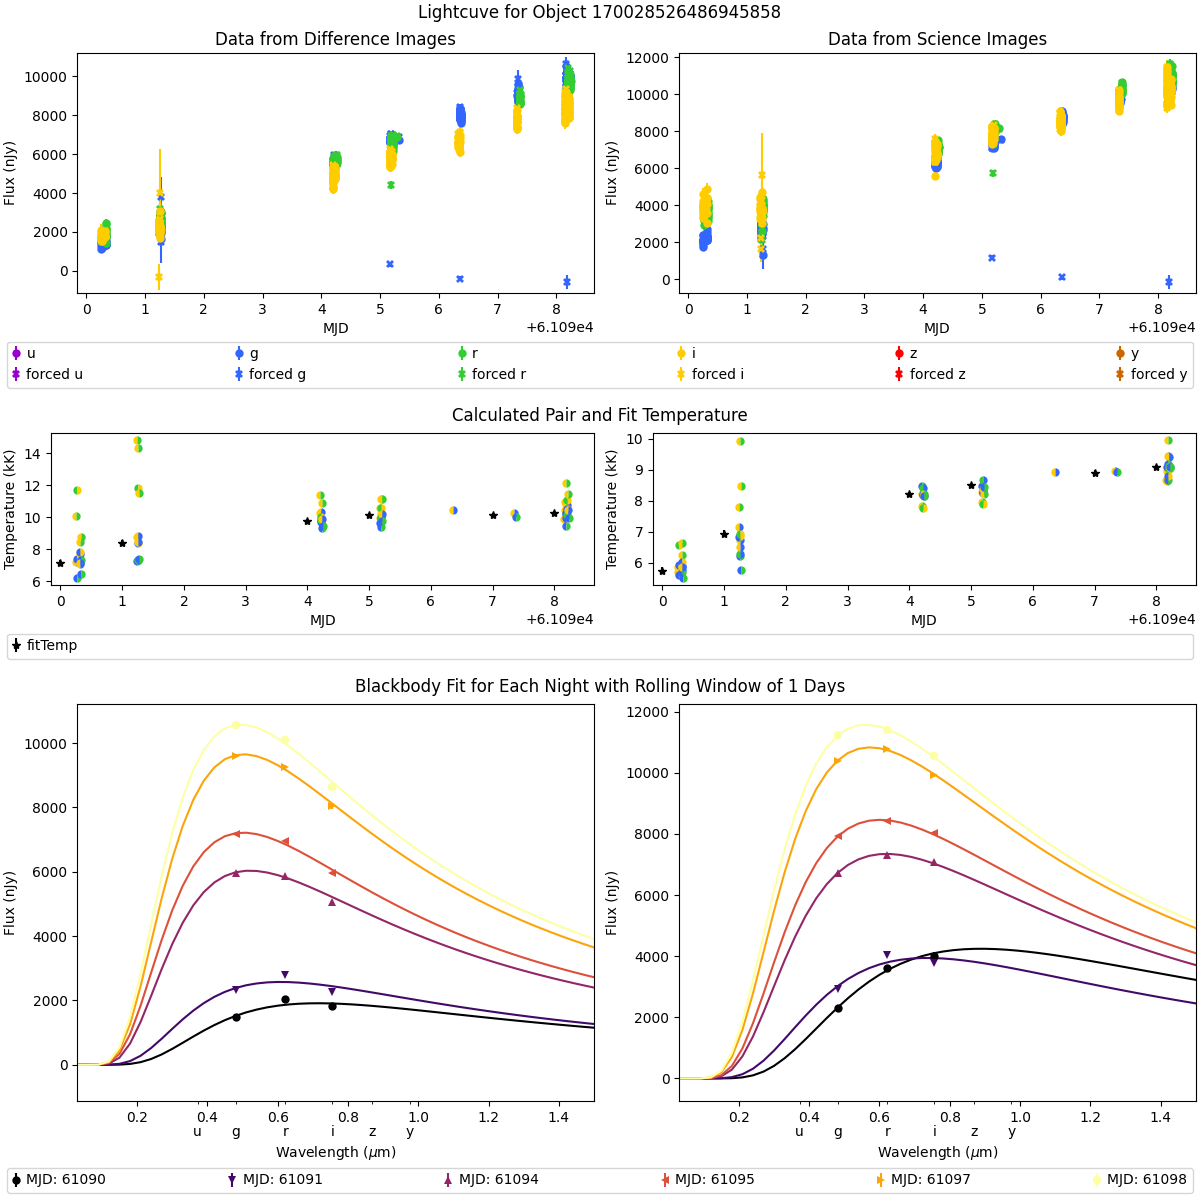

In [80]:
diaObjectId = 170028526486945858
plotTemp(diaObjectId, save=True, update=False, window=1)

### Example 2 object 313853517401423939

Object Id: 313853517401423939
Removed outliers:
|      |   midpointMjdTai |   differenceFlux |   differenceFluxErr |   scienceFlux |   scienceFluxErr |   reliability | band   | isForced   |
|-----:|-----------------:|-----------------:|--------------------:|--------------:|-----------------:|--------------:|:-------|:-----------|
| 1538 |            61189 |         -13786   |             426.572 |       3727.04 |           431.18 |            -1 | g      | True       |
| 1574 |            61198 |          41056.2 |           29298     |      65183.7  |         29487.8  |            -1 | r      | True       |
| 1576 |            61198 |         -48203   |          286400     |    -124288    |        287833    |            -1 | y      | True       |
| 1577 |            61198 |          32345.8 |          113263     |      45004.1  |        114148    |            -1 | y      | True       |
Failed Fits:
|    |   MJD | Wavelengths                    | Fluxes                                 

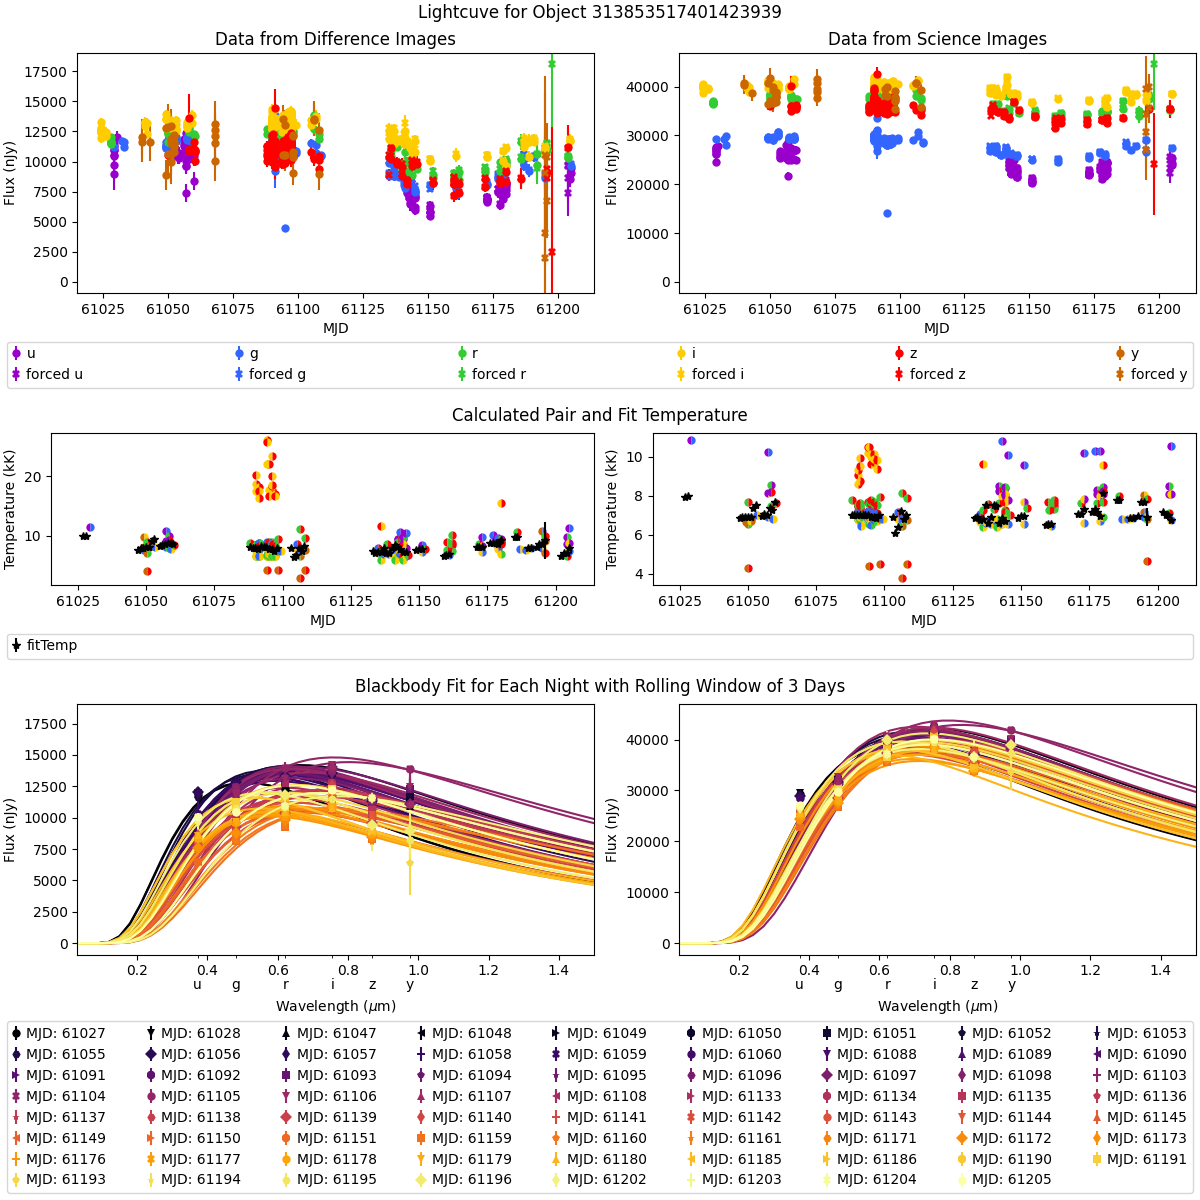

In [81]:
diaObjectId = 313853517401423939
plotTemp(diaObjectId, save=True, update=False, window=3)

### Example 3 object 313928194477522960

Object Id: 313928194477522960
Fit Temperature Statistics:
|                 | Weighted 3 Sigma Mean   | Standard Deviation   | Median   |
|:----------------|:------------------------|:---------------------|:---------|
| Difference Flux | 3.941 kK                | 1.613 kK             | 6.360 kK |
| Science Flux    | 3.899 kK                | 1.094 kK             | 5.329 kK |


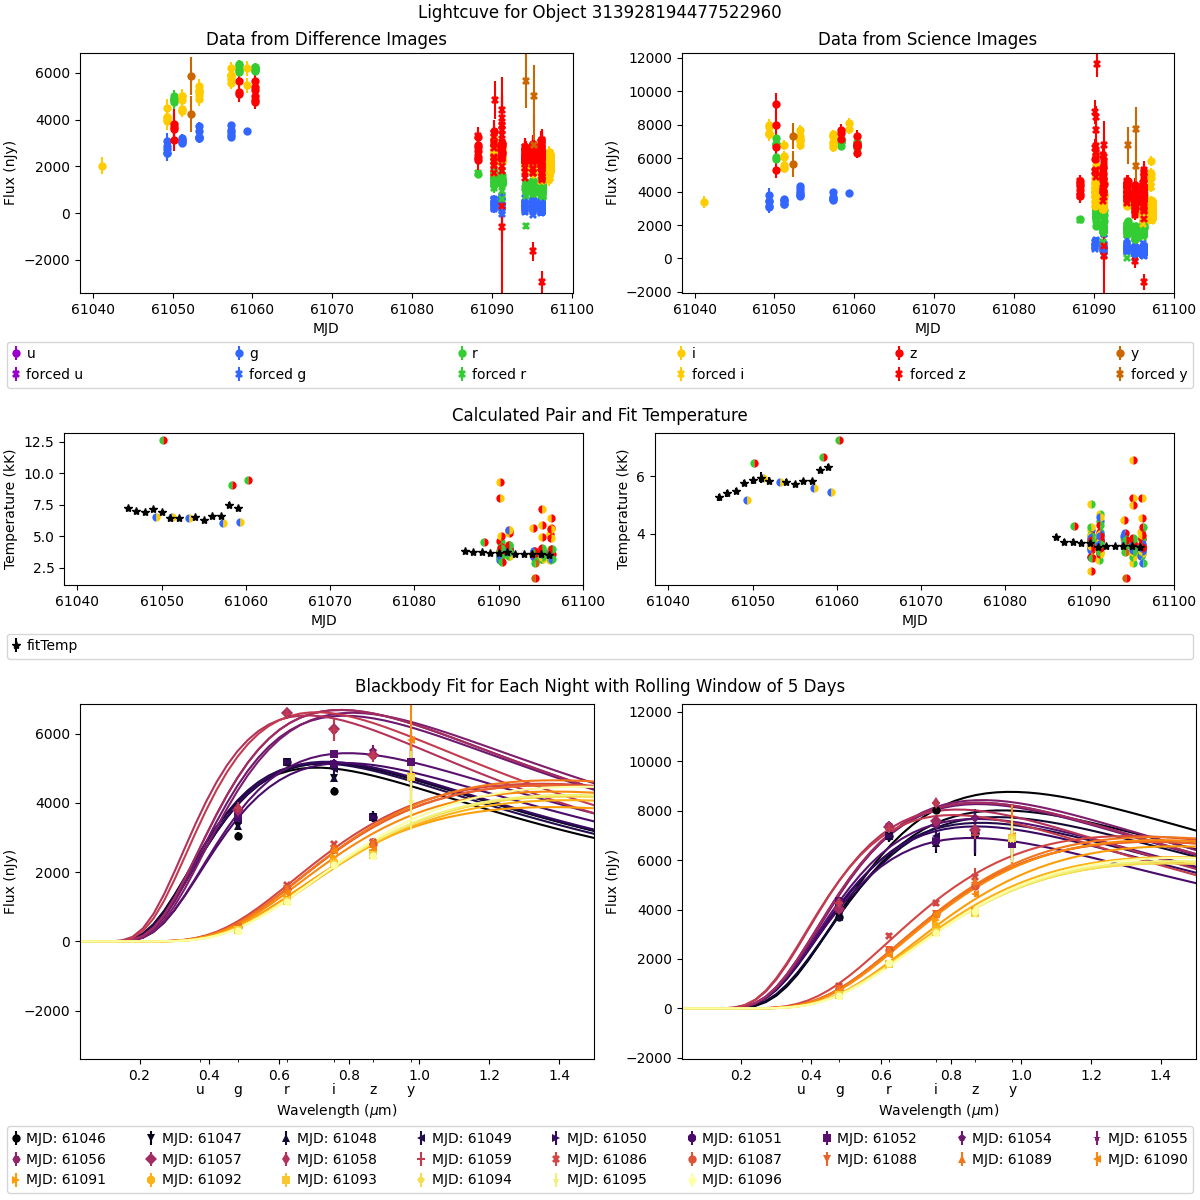

In [82]:
diaObjectId = 313928194477522960
plotTemp(diaObjectId, save=True, update=False, window=5)

### Example 4 object 313853517416628317 compared to GAIA
Gaia DR3 3848359966449030272

Teff    7070 [7039, 7110]	K

Object Id: 313853517416628317
|    |      ra |     dec | type   |    ra_1 |   dec_1 |   teff_gspphot |   teff_gspphot_lower |   teff_gspphot_upper |   separation_arcsec |
|---:|--------:|--------:|:-------|--------:|--------:|---------------:|---------------------:|---------------------:|--------------------:|
|  0 | 149.023 | 2.88108 | agn    | 149.023 | 2.88108 |        7069.84 |               7038.9 |              7109.75 |           0.0337231 |
Removed outliers:
|      |   midpointMjdTai |   differenceFlux |   differenceFluxErr |   scienceFlux |   scienceFluxErr |   reliability | band   | isForced   |
|-----:|-----------------:|-----------------:|--------------------:|--------------:|-----------------:|--------------:|:-------|:-----------|
| 1246 |            61198 |          62391.3 |             64827.6 |        127087 |          65248.7 |            -1 | z      | True       |
Failed Fits:
|    |   MJD | Wavelengths        | Fluxes                      | Flux errors             

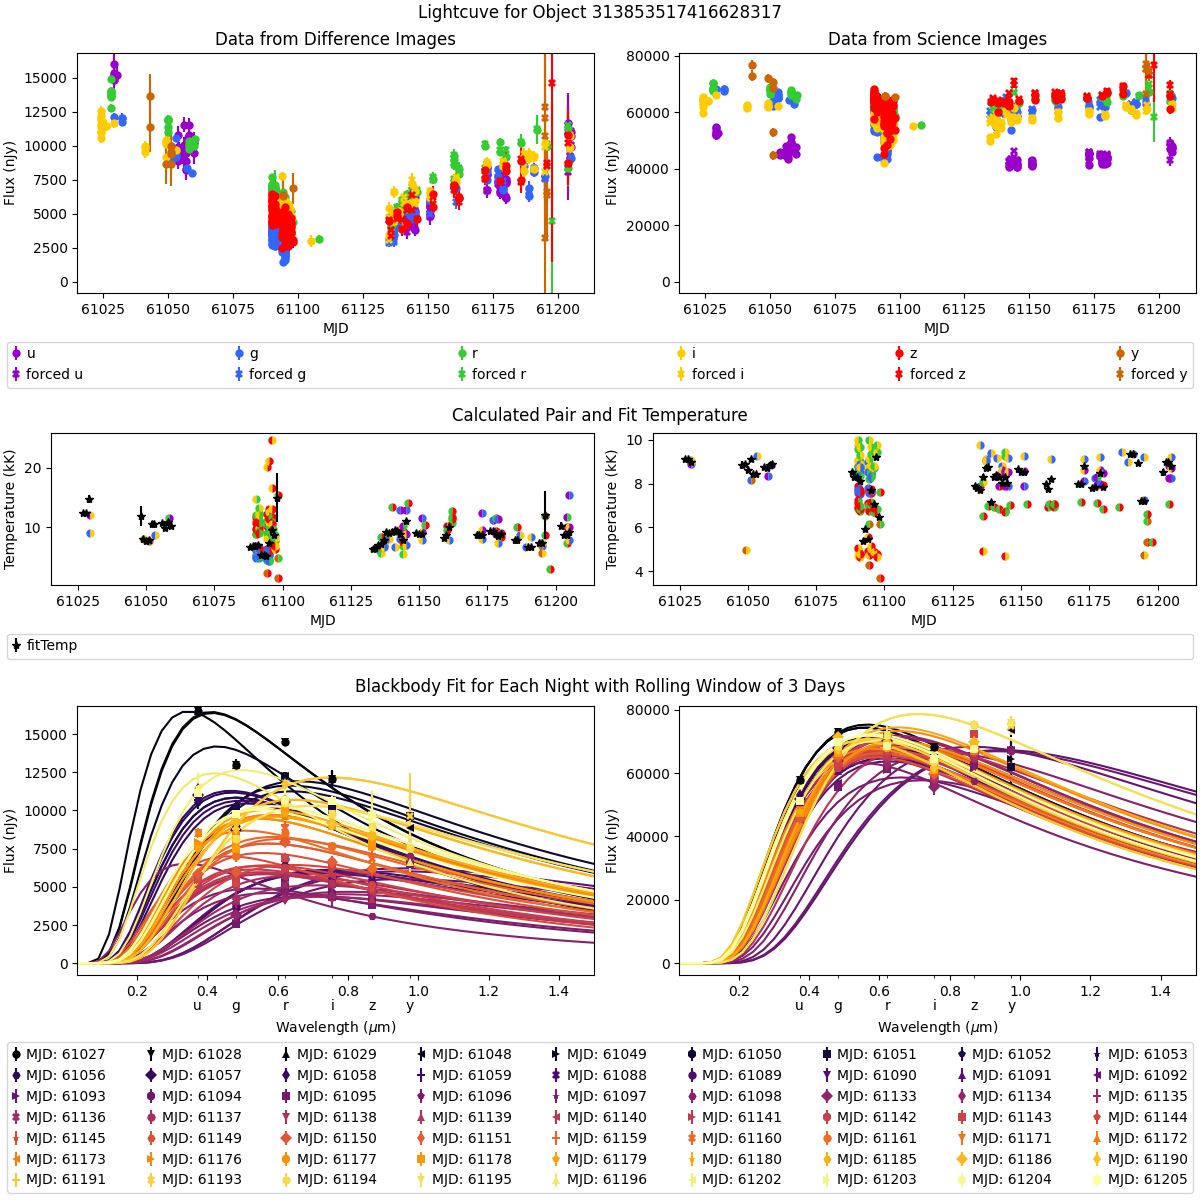

In [83]:
diaObjectId = 313853517416628317
plotTemp(diaObjectId, save=True, update=False, window=3)

### Example 5 object 313875415093477395 compared to GAIA
Gaia DR3 3836000768557705344

Teff	6132 [6108, 6153]	K

Object Id: 313875415093477395
Removed outliers:
|      |   midpointMjdTai |   differenceFlux |   differenceFluxErr |   scienceFlux |   scienceFluxErr |   reliability | band   | isForced   |
|-----:|-----------------:|-----------------:|--------------------:|--------------:|-----------------:|--------------:|:-------|:-----------|
|  839 |          61137.2 |         -35450.3 |             433.729 |       69005.8 |          428.764 |            -1 | i      | True       |
|  964 |          61173   |         -69308.3 |             287.353 |       35772.8 |          279.416 |            -1 | i      | True       |
| 1082 |          61198   |         147905   |          251663     |      243185   |       253472     |            -1 | y      | True       |
Failed Fits:
|    |   MJD | Wavelengths        | Fluxes                        | Flux errors             |
|---:|------:|:-------------------|:------------------------------|:------------------------|
|  0 | 61202 | [0.37, 0.62, 0.87] | [3479

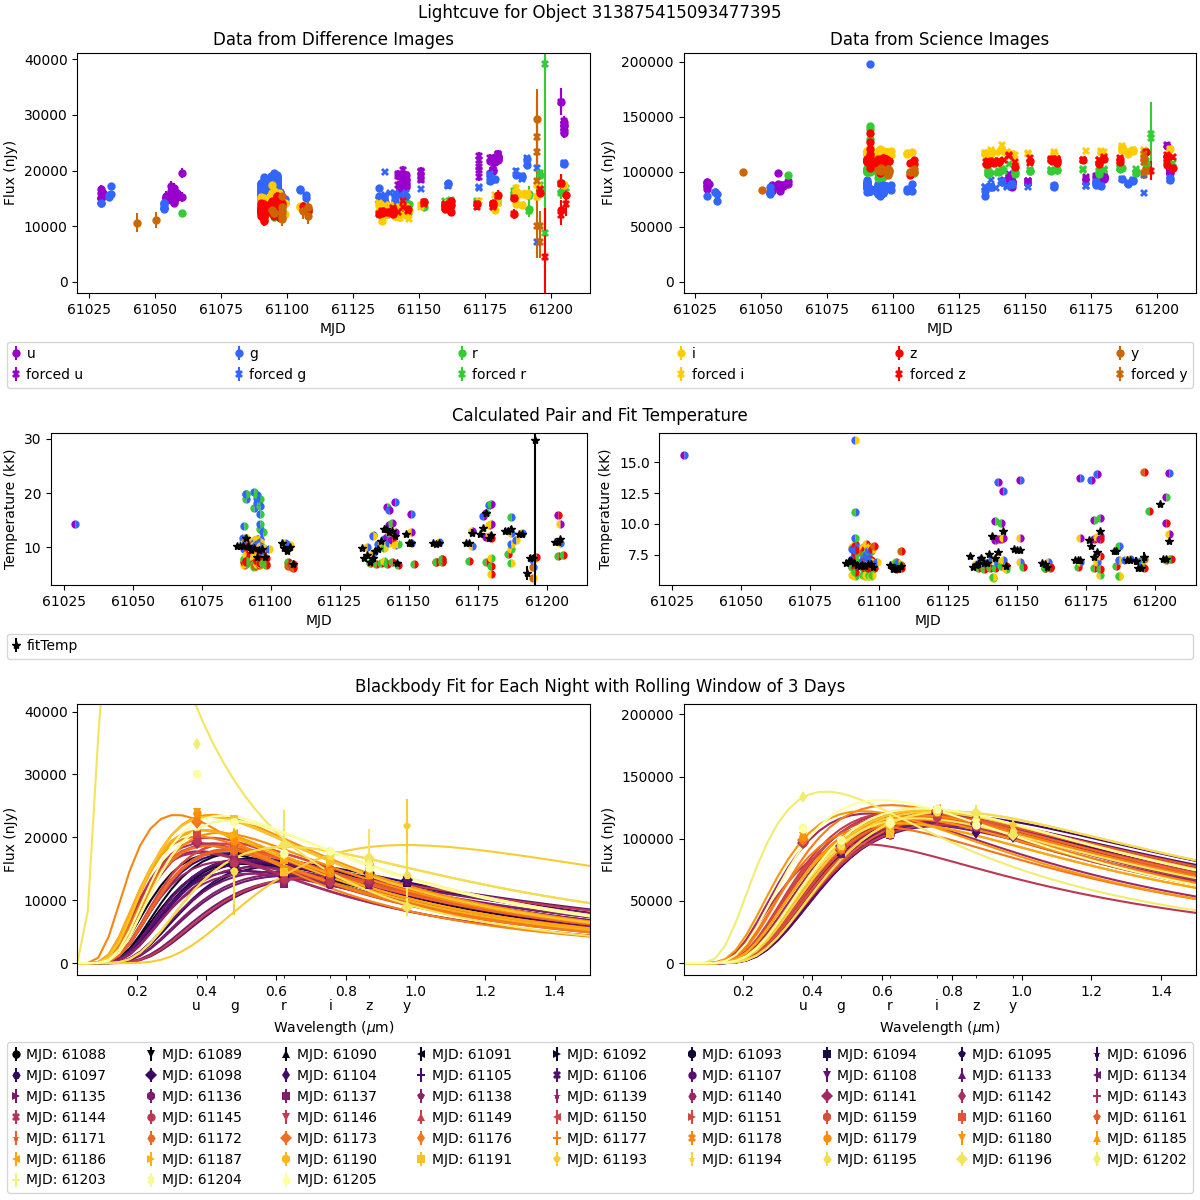

In [84]:
diaObjectId = 313875415093477395
plotTemp(diaObjectId, save=True, update=False, window=3)

### Example 6 object 313875415068311567 compared to GAIA
Gaia DR3 3836290318072886656

Teff	6233 [6196, 6263]	K

Object Id: 313875415068311567
|    |      ra |     dec | type   |    ra_1 |   dec_1 |   teff_gspphot |   teff_gspphot_lower |   teff_gspphot_upper |   separation_arcsec |
|---:|--------:|--------:|:-------|--------:|--------:|---------------:|---------------------:|---------------------:|--------------------:|
|  0 | 150.054 | 2.58968 | agn    | 150.054 | 2.58967 |        6232.76 |              6195.78 |              6263.01 |           0.0332644 |
Removed outliers:
|      |   midpointMjdTai |   differenceFlux |   differenceFluxErr |   scienceFlux |   scienceFluxErr |   reliability | band   | isForced   |
|-----:|-----------------:|-----------------:|--------------------:|--------------:|-----------------:|--------------:|:-------|:-----------|
|  836 |          61145.1 |           -60085 |             350.716 |      46865.8  |          343.062 |            -1 | i      | True       |
|  951 |          61179   |          -100049 |             193.54  |       1971.92 |          181.705 |

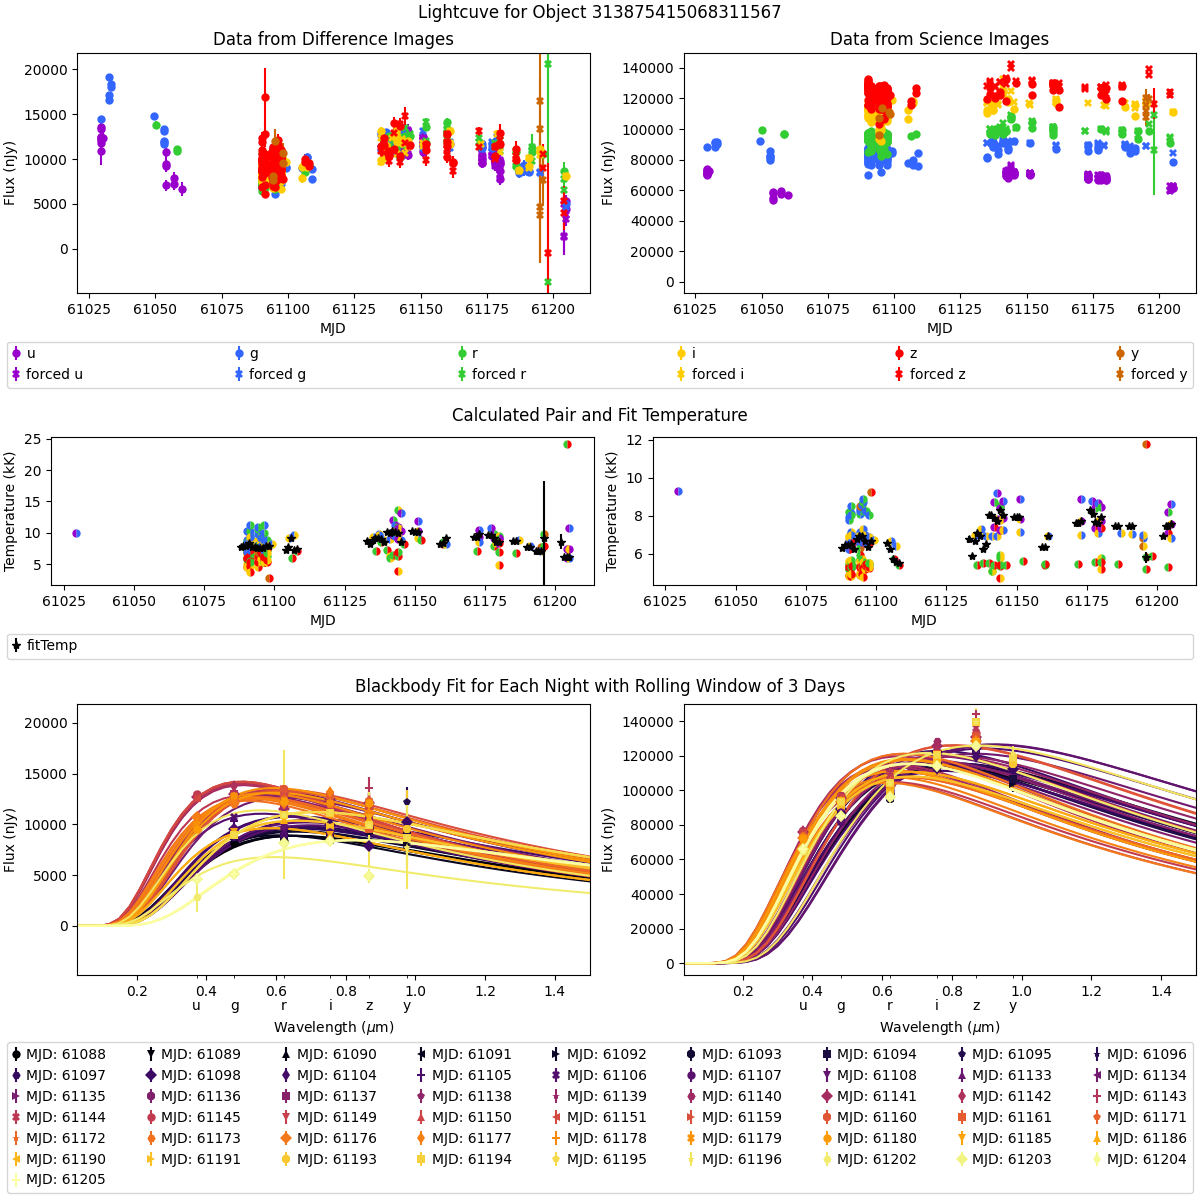

In [85]:
diaObjectId = 313875415068311567
plotTemp(diaObjectId, save=True, update=False, window=3)

### Example 7 rrlyrae object 313976545432567829 compared to GAIA

Object Id: 313976545432567829
|    |      ra |    dec | type    |    ra_1 |   dec_1 |   teff_gspphot |   teff_gspphot_lower |   teff_gspphot_upper |   separation_arcsec |
|---:|--------:|-------:|:--------|--------:|--------:|---------------:|---------------------:|---------------------:|--------------------:|
|  0 | 150.527 | 1.3757 | rrlyrae | 150.527 | 1.37571 |        6436.68 |              6370.28 |              6490.71 |           0.0471322 |
Failed Fits:
|    |   MJD | Wavelengths        | Fluxes                               | Flux errors                 |
|---:|------:|:-------------------|:-------------------------------------|:----------------------------|
|  0 | 61135 | [0.48, 0.76, 0.87] | [-691016.05, -112681.49, -130797.65] | [2803.77, 238.34, 104.55]   |
|  1 | 61142 | [0.37, 0.62, 0.87] | [-98970.4, -148757.47, 126074.06]    | [4065.55, 2104.31, 1182.42] |
Failed Fits:
|    |   MJD | Wavelengths        | Fluxes                            | Flux errors               |
|

C:\Users\wagnernb\AppData\Local\Temp\ipykernel_1964\2710691343.py:15: RuntimeWarning: divide by zero encountered in power
  return np.ma.average(maskedFluxs, weights=np.pow(fluxErrs, -2)), error
c:\Users\wagnernb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\ma\extras.py:667: RuntimeWarning: invalid value encountered in scalar divide
  avg = np.multiply(a, wgt,
C:\Users\wagnernb\AppData\Local\Temp\ipykernel_1964\3153370296.py:5: RuntimeWarning: overflow encountered in exp
  q = np.exp(hck/(wl*T))


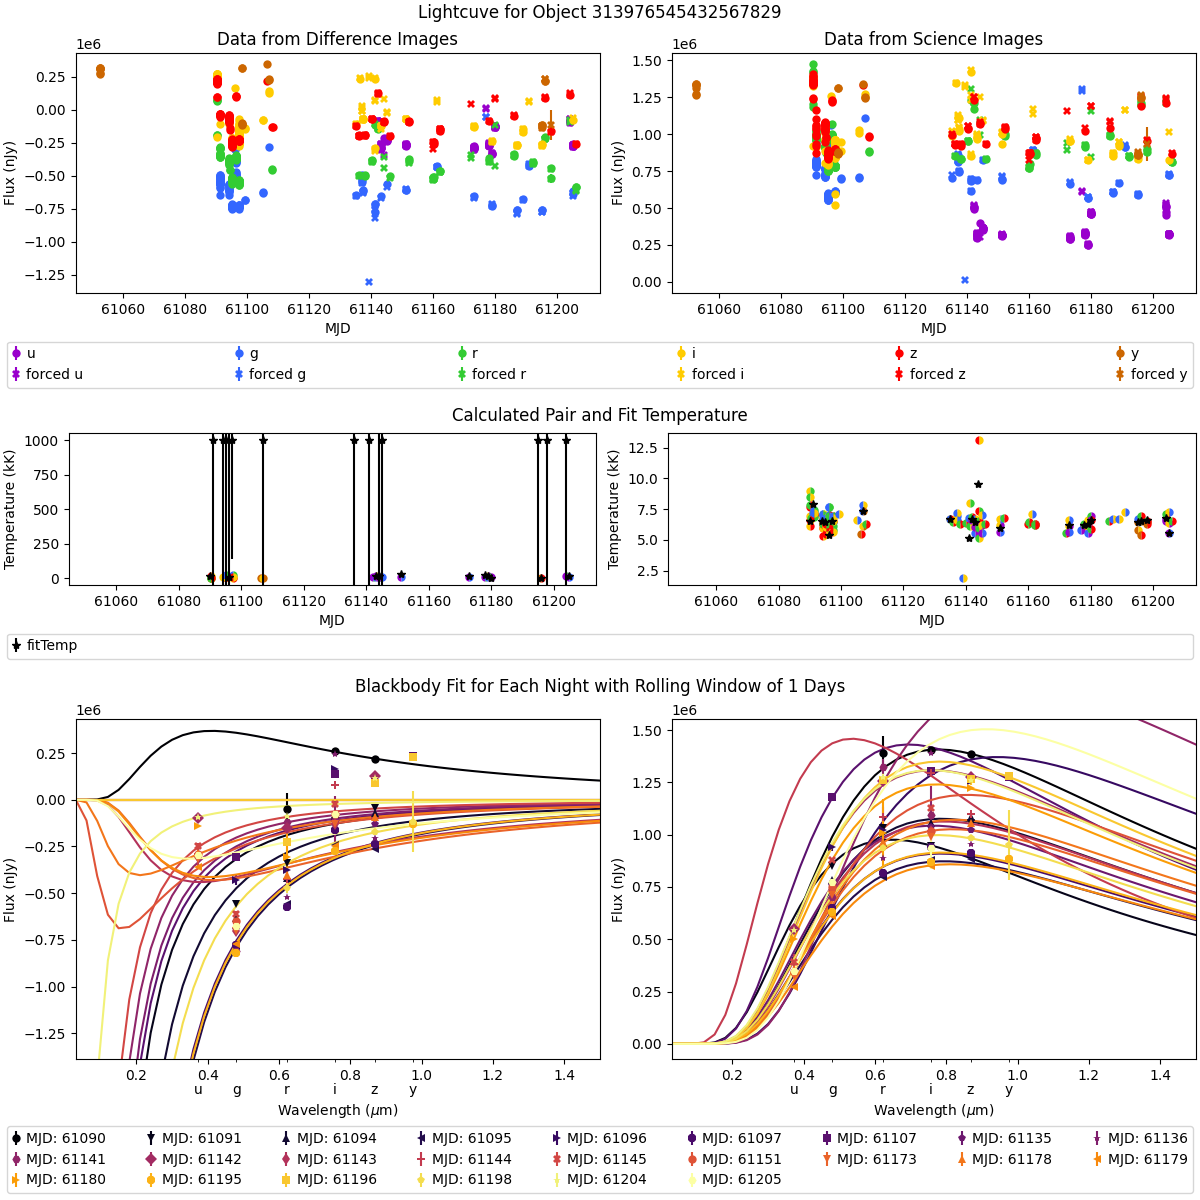

In [86]:
diaObjectId = 313976545432567829
plotTemp(diaObjectId, save=True, update=False, window=1)

### Example 8 rrlyrae object 313936986529333309 compared to GAIA

Object Id: 313936986529333309
|    |      ra |      dec | type    |    ra_1 |    dec_1 |   teff_gspphot |   teff_gspphot_lower |   teff_gspphot_upper |   separation_arcsec |
|---:|--------:|---------:|:--------|--------:|---------:|---------------:|---------------------:|---------------------:|--------------------:|
|  0 | 150.125 | 0.877581 | rrlyrae | 150.125 | 0.877592 |           7130 |              7098.93 |              7159.98 |           0.0404991 |
Failed Fits:
|    |   MJD | Wavelengths              | Fluxes                                    | Flux errors                           |
|---:|------:|:-------------------------|:------------------------------------------|:--------------------------------------|
|  0 | 61094 | [0.48, 0.62, 0.76, 0.87] | [57407.72, 17427.73, 11804.42, -40869.25] | [11736.41, 20380.11, 9804.21, 1270.2] |
|  1 | 61143 | [0.37, 0.48, 0.76]       | [-39458.01, -45786.38, -50476.7]          | [15094.29, 2880.4, 48.81]             |
Failed Fits:
|    |  

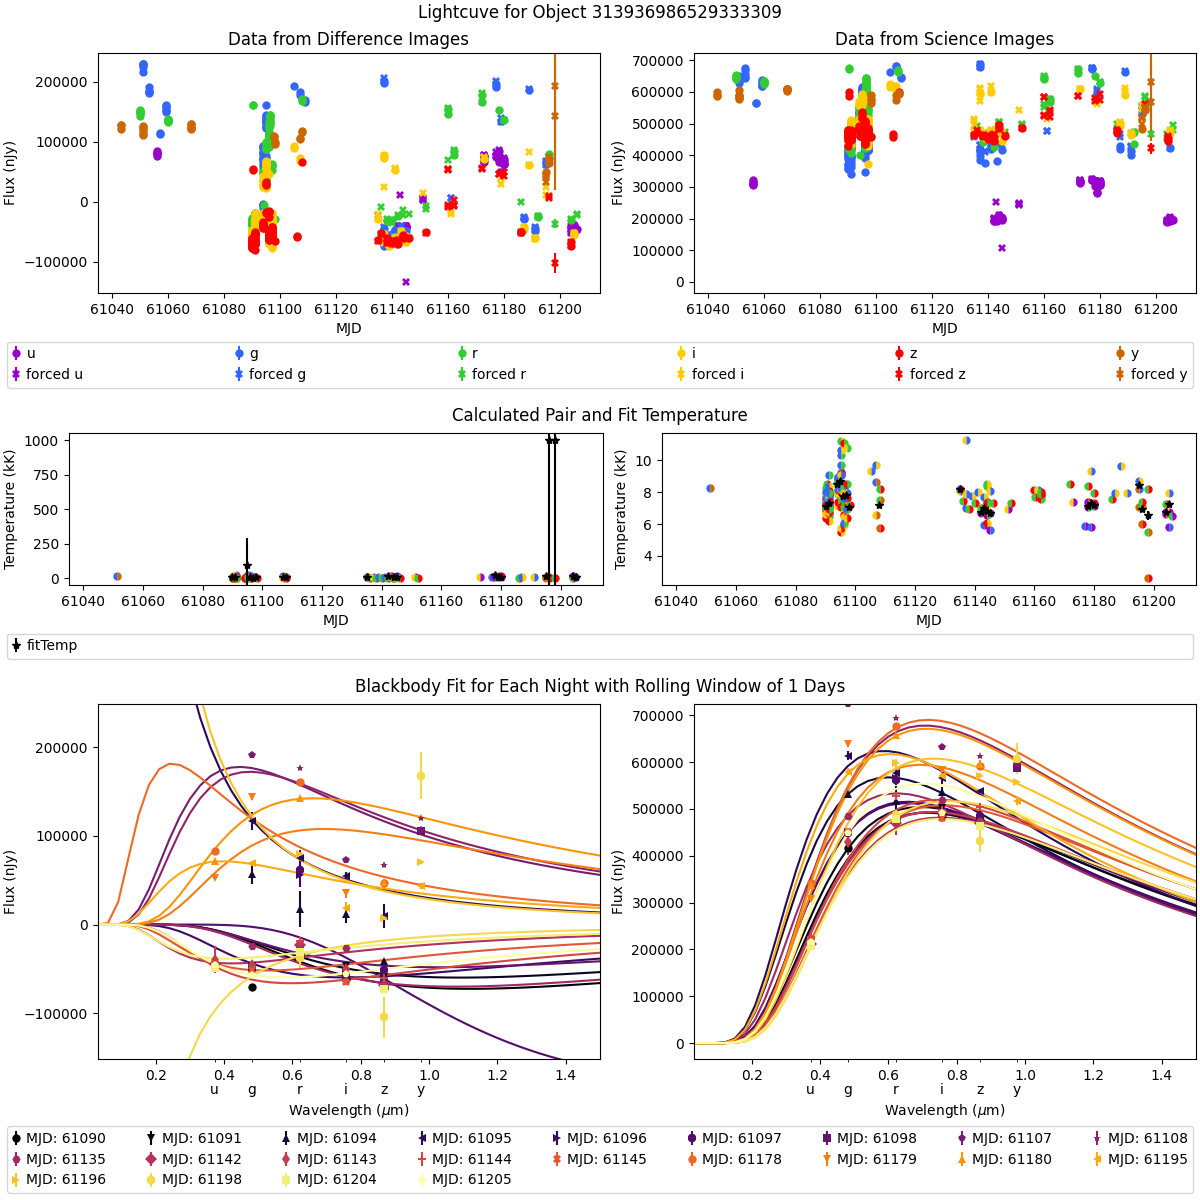

In [87]:
diaObjectId = 313936986529333309
plotTemp(diaObjectId, save=True, update=False, window=1)

### Example 9 short_timescale object 170028486904250400 compared to GAIA

Object Id: 170028486904250400
|    |      ra |      dec | type            |    ra_1 |    dec_1 |   teff_gspphot |   teff_gspphot_lower |   teff_gspphot_upper |   separation_arcsec |
|---:|--------:|---------:|:----------------|--------:|---------:|---------------:|---------------------:|---------------------:|--------------------:|
|  0 | 57.6852 | -48.9056 | short_timescale | 57.6852 | -48.9056 |        3424.69 |              3416.23 |              3436.28 |            0.114508 |
Removed outliers:
|     |   midpointMjdTai |   differenceFlux |   differenceFluxErr |   scienceFlux |   scienceFluxErr |   reliability | band   | isForced   |
|----:|-----------------:|-----------------:|--------------------:|--------------:|-----------------:|--------------:|:-------|:-----------|
| 260 |          61095.1 |     -1.14972e+06 |             493.551 |       4140.19 |          387.382 |            -1 | z      | True       |
Failed Fits:
|    |   MJD | Wavelengths              | Fluxes            

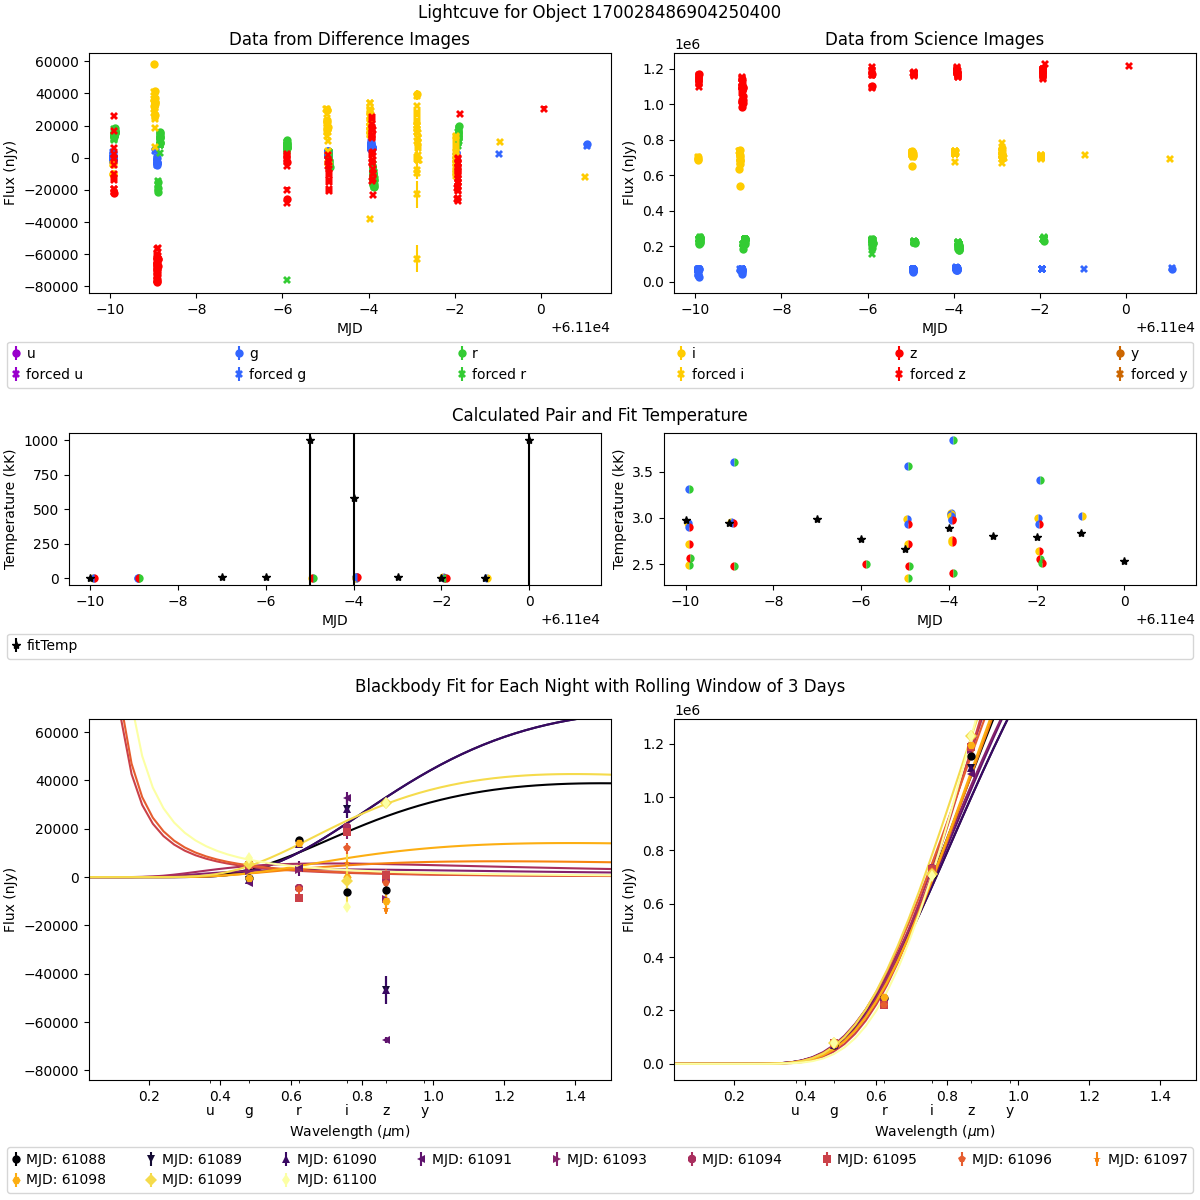

In [88]:
diaObjectId = 170028486904250400
plotTemp(diaObjectId, save=True, update=False, window=3)

### Example 10 ms_oscillator object 170028486090555526 compared to GAIA

Object Id: 170028486090555526
|    |     ra |      dec | type          |   ra_1 |    dec_1 |   teff_gspphot |   teff_gspphot_lower |   teff_gspphot_upper |   separation_arcsec |
|---:|-------:|---------:|:--------------|-------:|---------:|---------------:|---------------------:|---------------------:|--------------------:|
|  0 | 58.002 | -49.5748 | ms_oscillator | 58.002 | -49.5748 |        7322.53 |              7303.91 |              7343.72 |           0.0966094 |
Failed Fits:
|    |   MJD | Wavelengths              | Fluxes                                | Flux errors                         |
|---:|------:|:-------------------------|:--------------------------------------|:------------------------------------|
|  0 | 61097 | [0.48, 0.62, 0.76, 0.87] | [8807.96, 14495.5, 1074.88, -7365.49] | [2974.36, 1496.04, 1314.83, 479.69] |
|  1 | 61098 | [0.48, 0.62, 0.76, 0.87] | [8807.96, 14059.28, 1039.52, -7226.2] | [2974.36, 1551.01, 2212.32, 501.27] |
Fit Temperature Statistics:
|    

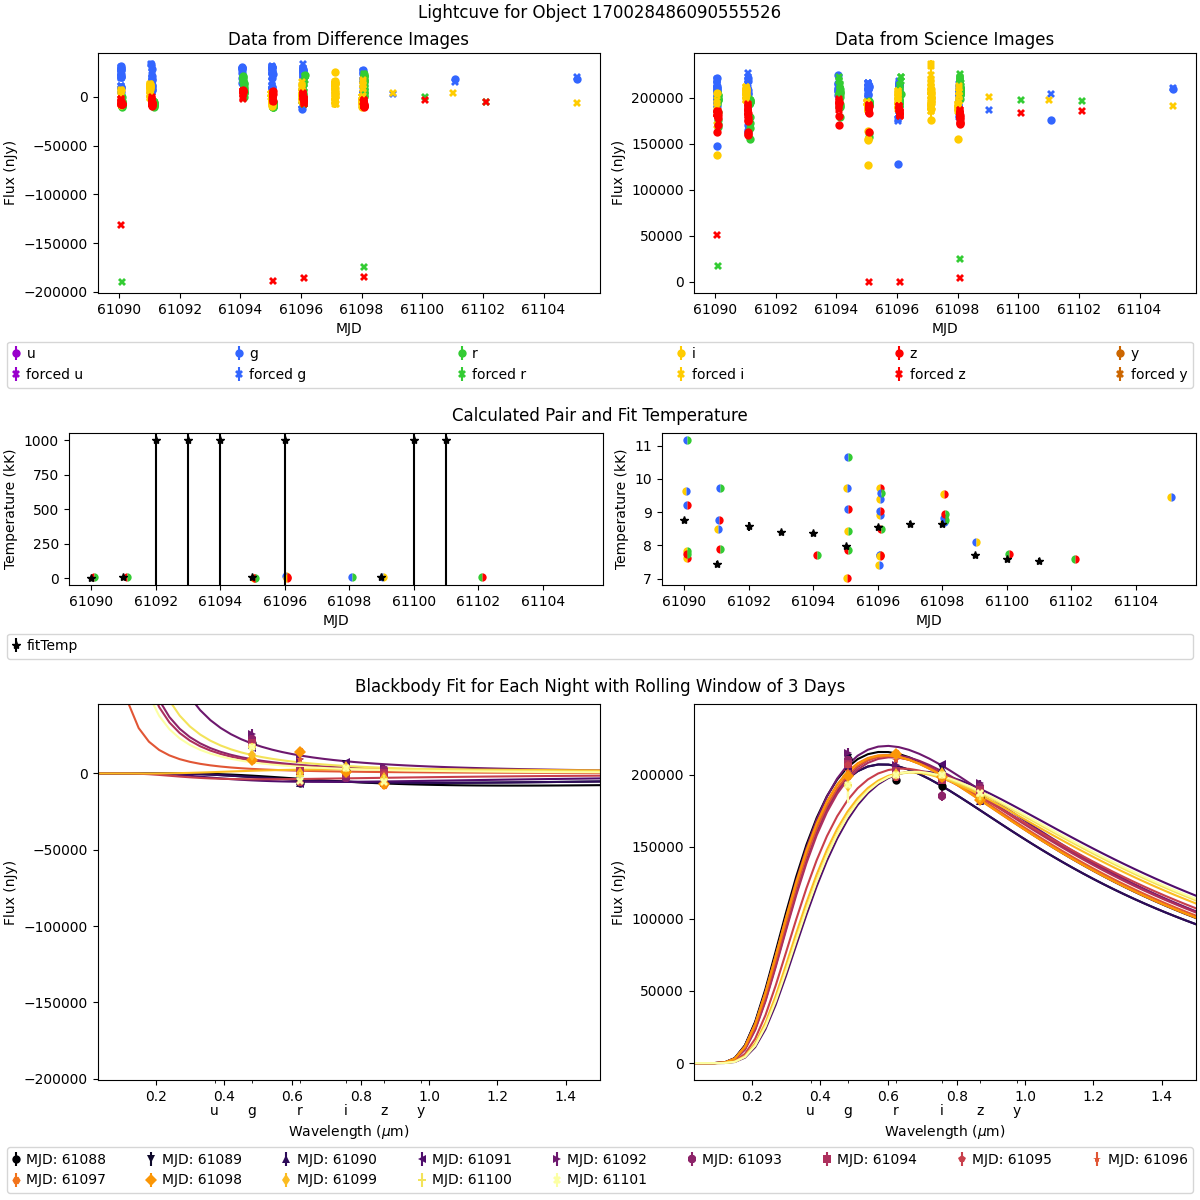

In [89]:
diaObjectId = 170028486090555526
plotTemp(diaObjectId, save=True, update=False, window=3)

## Find objects of interest in both Gaia and LSST data

In [23]:
bqclient = pittgoogle.bigquery.Client() # load the BigQuery client

sqlGaiaMatchQuery = f"""
WITH latest_alert AS (
    SELECT DISTINCT
    alerts.diaObject.diaObjectId,
    alerts.diaObject.nDiaSources,
    alerts.diaObject.ra,
    alerts.diaObject.dec,
    FROM `pitt-alert-broker.lsst.alerts_v10_0` as alerts
    WHERE alerts.diaObject.nDiaSources > 100

    UNION DISTINCT

    SELECT DISTINCT
    alerts.diaObject.diaObjectId,
    alerts.diaObject.nDiaSources,
    alerts.diaObject.ra,
    alerts.diaObject.dec,
    FROM `pitt-alert-broker.lsst.alerts_v11_0` as alerts
    WHERE alerts.diaObject.nDiaSources > 100

    LIMIT 1000
),

xmatch_gaia AS (
    SELECT
    'cepheid' AS type,
    gaia.ra,
    gaia.dec,
    gaia.teff_gspphot,
    gaia.teff_gspphot_lower,
    gaia.teff_gspphot_upper,
    FROM `pitt-alert-broker.xmatch_gaia.cepheid` as gaia

    UNION ALL

    SELECT
    'rrlyrae' AS type,
    gaia.ra,
    gaia.dec,
    gaia.teff_gspphot,
    gaia.teff_gspphot_lower,
    gaia.teff_gspphot_upper,
    FROM `pitt-alert-broker.xmatch_gaia.rrlyrae` as gaia
)

SELECT
    a.*,
    g.*,
    SQRT(
        POW((g.ra - a.ra) * 3.1415 / 180.0 * COS(a.dec * 3.1415 / 180.0), 2) +
        POW((g.dec - a.dec) * 3.1415 / 180.0, 2)
    ) * 180 / 3.1415 * 3600.0 AS separation_arcsec
FROM latest_alert a
JOIN xmatch_gaia g ON
    ABS(g.ra - a.ra) < 0.01
    AND ABS(g.dec - a.dec) < 0.01
"""

bqclient.query(query=sqlGaiaMatchQuery, dry_run=True)
gaia = bqclient.query(query=sqlGaiaMatchQuery)
gaia

This query will process 367,972,120 bytes


,diaObjectId,nDiaSources,ra,dec,type,ra_1,dec_1,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,separation_arcsec
0,313875415246569500,391,150.802183,0.972132,rrlyrae,150.802204,0.972144,6457.4700,6426.1730,6493.1210,0.084998
1,313985345023639575,782,149.685921,2.521655,rrlyrae,149.685927,2.521667,6487.4775,6458.7640,6565.8115,0.049252
2,314003014011584569,211,150.651766,3.002574,rrlyrae,150.648599,3.006504,5745.8286,5707.9260,5792.6460,18.159998
3,313936986529333309,767,150.124522,0.877581,rrlyrae,150.124522,0.877592,7129.9966,7098.9310,7159.9760,0.040563
4,313967766913679434,395,150.648605,3.006490,rrlyrae,150.648599,3.006504,5745.8286,5707.9260,5792.6460,0.056160
5,313976545432567829,705,150.527283,1.375699,rrlyrae,150.527285,1.375712,6436.6800,6370.2820,6490.7085,0.046765
6,313967766913679434,397,150.648605,3.006490,rrlyrae,150.648599,3.006504,5745.8286,5707.9260,5792.6460,0.056018
7,313967766913679434,346,150.648606,3.006490,rrlyrae,150.648599,3.006504,5745.8286,5707.9260,5792.6460,0.058731
8,313888627074007083,360,149.136921,1.284973,rrlyrae,149.136933,1.284986,6858.6763,6702.3145,6949.3164,0.062491
9,170028526533607595,378,187.636371,6.363861,rrlyrae,187.636369,6.363872,6257.4575,6229.6226,6280.6020,0.041034


In [24]:
bqclient = pittgoogle.bigquery.Client() # load the BigQuery client

sqlGaiaMatchQuery = f"""
WITH latest_alert AS (
    SELECT DISTINCT
    alerts.diaObject.diaObjectId,
    alerts.diaObject.nDiaSources,
    alerts.diaObject.ra,
    alerts.diaObject.dec,
    FROM `pitt-alert-broker.lsst.alerts_v10_0` as alerts
    WHERE alerts.diaObject.nDiaSources > 100

    UNION DISTINCT

    SELECT DISTINCT
    alerts.diaObject.diaObjectId,
    alerts.diaObject.nDiaSources,
    alerts.diaObject.ra,
    alerts.diaObject.dec,
    FROM `pitt-alert-broker.lsst.alerts_v11_0` as alerts
    WHERE alerts.diaObject.nDiaSources > 100

    LIMIT 100000
),

xmatch_gaia AS (
    SELECT
    'cepheid' AS type,
    gaia.ra,
    gaia.dec,
    gaia.teff_gspphot,
    gaia.teff_gspphot_lower,
    gaia.teff_gspphot_upper,
    FROM `pitt-alert-broker.xmatch_gaia.cepheid` as gaia

    UNION ALL

    SELECT
    'long_period_variable' AS type,
    gaia.ra,
    gaia.dec,
    gaia.teff_gspphot,
    gaia.teff_gspphot_lower,
    gaia.teff_gspphot_upper,
    FROM `pitt-alert-broker.xmatch_gaia.long_period_variable` as gaia

    UNION ALL

    SELECT
    'ms_oscillator' AS type,
    gaia.ra,
    gaia.dec,
    gaia.teff_gspphot,
    gaia.teff_gspphot_lower,
    gaia.teff_gspphot_upper,
    FROM `pitt-alert-broker.xmatch_gaia.ms_oscillator` as gaia

    UNION ALL

    SELECT
    'rotation_modulation' AS type,
    gaia.ra,
    gaia.dec,
    gaia.teff_gspphot,
    gaia.teff_gspphot_lower,
    gaia.teff_gspphot_upper,
    FROM `pitt-alert-broker.xmatch_gaia.rotation_modulation` as gaia

    UNION ALL

    SELECT
    'short_timescale' AS type,
    gaia.ra,
    gaia.dec,
    gaia.teff_gspphot,
    gaia.teff_gspphot_lower,
    gaia.teff_gspphot_upper,
    FROM `pitt-alert-broker.xmatch_gaia.short_timescale` as gaia
)

SELECT
    a.*,
    g.*,
    SQRT(
        POW((g.ra - a.ra) * 3.1415 / 180.0 * COS(a.dec * 3.1415 / 180.0), 2) +
        POW((g.dec - a.dec) * 3.1415 / 180.0, 2)
    ) * 180 / 3.1415 * 3600.0 AS separation_arcsec
FROM latest_alert a
JOIN xmatch_gaia g ON
    ABS(g.ra - a.ra) < 0.01
    AND ABS(g.dec - a.dec) < 0.01
"""

bqclient.query(query=sqlGaiaMatchQuery, dry_run=True)
gaia = bqclient.query(query=sqlGaiaMatchQuery)
gaia

This query will process 442,213,072 bytes


,diaObjectId,nDiaSources,ra,dec,type,ra_1,dec_1,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,separation_arcsec
0,313761042215206924,170,60.096101,-49.553470,short_timescale,60.095940,-49.553428,4025.7030,4018.6194,4033.2815,0.406607
1,313761042215206924,140,60.096106,-49.553472,short_timescale,60.095940,-49.553428,4025.7030,4018.6194,4033.2815,0.419580
2,313761042215206924,179,60.096101,-49.553469,short_timescale,60.095940,-49.553428,4025.7030,4018.6194,4033.2815,0.405400
3,170028486090555526,105,58.002003,-49.574784,ms_oscillator,58.001965,-49.574777,7322.5310,7303.9100,7343.7220,0.093012
4,170028486904250400,128,57.685161,-48.905572,short_timescale,57.685154,-48.905604,3424.6880,3416.2285,3436.2812,0.114668
5,170028488677916741,121,61.635793,-46.980361,short_timescale,61.635812,-46.980384,3829.8696,3806.9329,3878.2979,0.094401
6,170028486904250400,138,57.685168,-48.905574,short_timescale,57.685154,-48.905604,3424.6880,3416.2285,3436.2812,0.113332
7,313761042216255531,110,59.344508,-49.752912,short_timescale,59.345918,-49.761069,4881.3984,4852.0337,4911.9900,29.550303
8,313761042215206924,175,60.096101,-49.553470,short_timescale,60.095940,-49.553428,4025.7030,4018.6194,4033.2815,0.405553
9,170028486090555526,109,58.002001,-49.574784,ms_oscillator,58.001965,-49.574777,7322.5310,7303.9100,7343.7220,0.087863


In [25]:
import pandas as pd
pd.set_option('display.max_rows', 500)
alerts_tbl = pittgoogle.bigquery.Table(name="agn", dataset="xmatch_gaia", projectid=pgb_project)
alerts_tbl.schema

,name,type,mode
0,solution_id_var,INTEGER,NULLABLE
1,source_id,INTEGER,NULLABLE
2,fractional_variability_g,FLOAT,NULLABLE
3,structure_function_index,FLOAT,NULLABLE
4,structure_function_index_scatter,FLOAT,NULLABLE
5,qso_variability,FLOAT,NULLABLE
6,non_qso_variability,FLOAT,NULLABLE
7,solution_id_gaia,INTEGER,NULLABLE
8,designation,STRING,NULLABLE
9,random_index,INTEGER,NULLABLE
